# Data Exploration: Survivorship Bias & Column Contribution

**Two goals:**
1. **Survivorship bias analysis** — separate populations, find the clean training window
2. **Column contribution analysis** — find which columns actually matter for prediction (Country × Client × Role × Skills per Quarter)

In [34]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Load raw data
# Full 2004–2026 picture, no filtering
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

conn = mysql.connector.connect(
    host='localhost', port=3305,
    database='resume_processing',
    user='resume_user', password='resume_password'
)

df = pd.read_sql("SELECT * FROM updated_job_records", conn)
conn.close()

# Parse dates
date_cols = ['issue_date', 'start_date', 'end_date', 'date_updated', 
             'date_status_updated', 'date_user_field_updated', 'submittal_due']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Total records: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Date range: {df['issue_date'].min()} → {df['issue_date'].max()}")
print(f"\nShape: {df.shape}")
df.head(3)

Total records: 190,056
Columns: 59
Date range: 2004-03-11 16:10:14 → 2026-06-05 08:16:30

Shape: (190056, 59)


,job_id,job_diva_no,optional_reference_no,division_id,division_name,primary_recruiter_id,primary_sales_id,primary_owner_id,updated_by,user_id,...,post_to_portal,secondary_division,skills,experience_level,vms_website,facility,bls_occupation,bls_occupation_id,eeoc_federal_sector_occupation,created_at
0,10000598,17-06354,NSAIJP00004530,244575,Talent-on-Demand,1377669,1377153,,,1388279,...,0,,(SYSTEMS ADMINISTRATOR OR SYSTEMS ENGINEER ),,,,,,,2026-06-05 13:47:18
1,10000721,17-06355,7317947,244575,Talent-on-Demand,1377163,1406036,,,1388279,...,0,,(PROJECT MANAGEMENT over 5 year(s) ) AND (PMP...,,,,,,,2026-06-05 13:47:18
2,10000724,17-06356,7418812,244575,Talent-on-Demand,1377163,1406036,,,1388279,...,0,,(HADOOP over 5 year(s) OR BIGDATA over 5 year...,,,,,,,2026-06-05 13:47:18


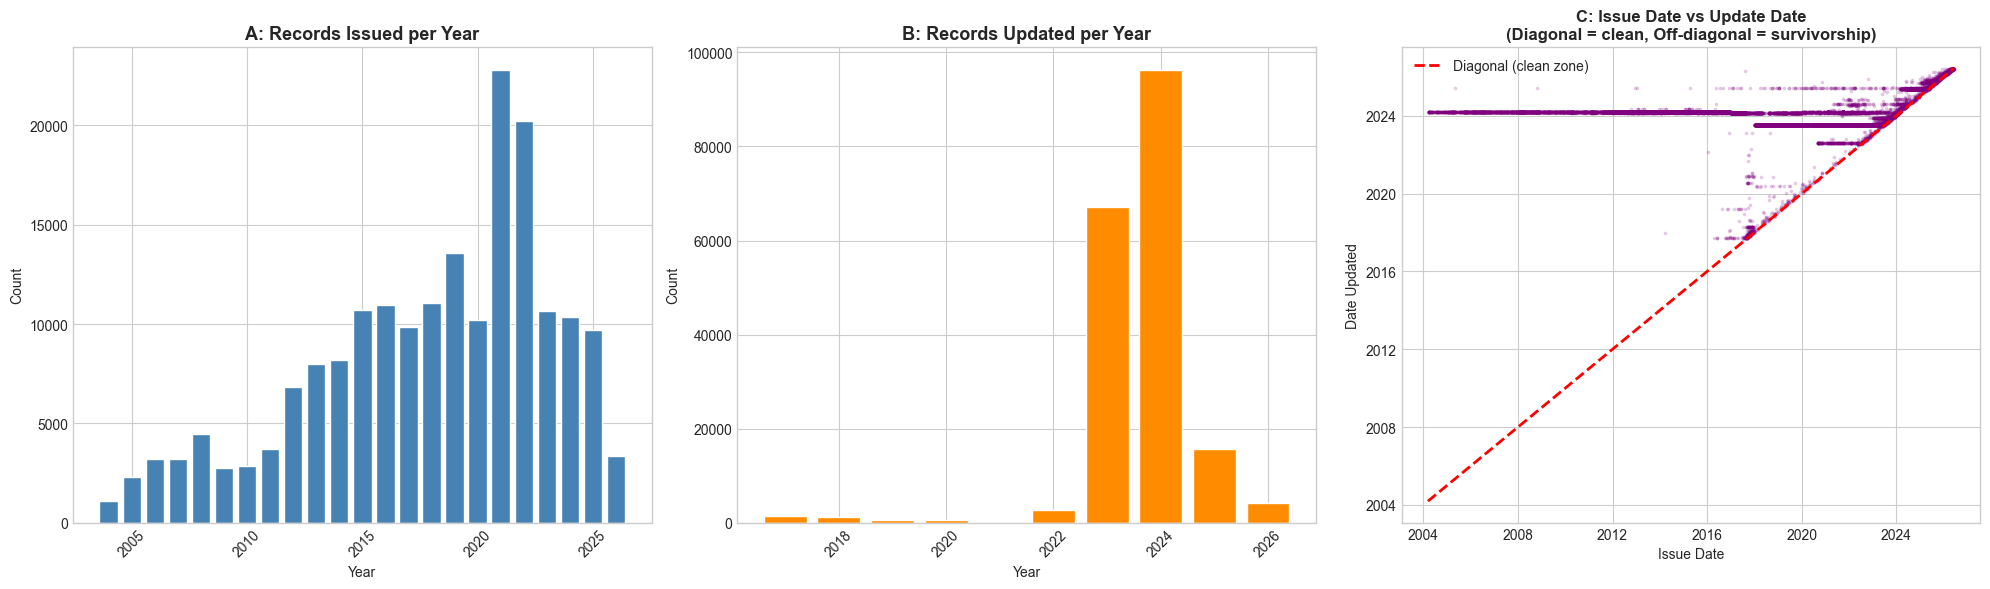


═══ Survivorship Groups (v2 threshold) ═══
survivorship_group
survivorship_artifact    124100
clean                     42016
moderate_lag              23940
Name: count, dtype: int64

Clean records: 42,016
  (Pre-2022: updated within 180 days | 2022+: updated within 365 days)


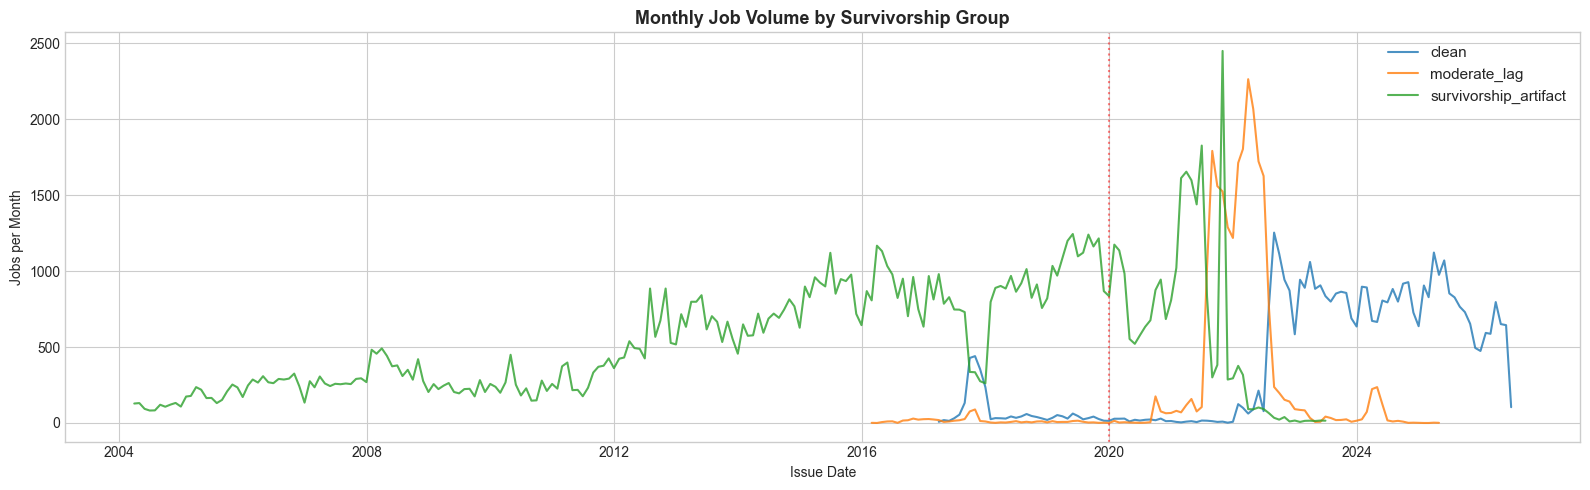


→ Training window: where the 'clean' line dominates (2019+).
  42k clean records form the training foundation.


In [36]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Survivorship bias plots
# Three plots:
#   A: issue_date histogram by year (records issued per year)
#   B: date_updated histogram by year (records touched per year)
#   C: scatter issue_date vs date_updated (the key survivorship plot)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot A: Records issued per year
df['issue_year'] = df['issue_date'].dt.year
issue_by_year = df['issue_year'].value_counts().sort_index()
axes[0].bar(issue_by_year.index, issue_by_year.values, color='steelblue', edgecolor='white')
axes[0].set_title('A: Records Issued per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot B: Records updated per year
df['updated_year'] = df['date_updated'].dt.year
updated_by_year = df['updated_year'].dropna().value_counts().sort_index()
axes[1].bar(updated_by_year.index, updated_by_year.values, color='darkorange', edgecolor='white')
axes[1].set_title('B: Records Updated per Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Plot C: Scatter — issue_date vs date_updated (SURVIVORSHIP KEY PLOT)
# Sample for performance if needed
sample = df.dropna(subset=['issue_date', 'date_updated'])
if len(sample) > 20000:
    sample = sample.sample(20000, random_state=42)

axes[2].scatter(sample['issue_date'], sample['date_updated'], 
               alpha=0.15, s=3, color='purple')
# Diagonal reference line (issued = updated same time)
min_date = df['issue_date'].min()
max_date = df['issue_date'].max()
axes[2].plot([min_date, max_date], [min_date, max_date], 
            'r--', linewidth=2, label='Diagonal (clean zone)')
axes[2].set_title('C: Issue Date vs Update Date\n(Diagonal = clean, Off-diagonal = survivorship)', 
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Issue Date')
axes[2].set_ylabel('Date Updated')
axes[2].legend()

plt.tight_layout()
plt.show()

# ── Define survivorship groups (v2 validated threshold) ──
# Threshold: 365 days for records issued 2022+ (validated in Cell 15)
#            180 days for records issued pre-2022 (strict)
# This recovers 11k records from 2022+ that were just slightly slow to update.
df['days_to_update'] = (df['date_updated'] - df['issue_date']).dt.days

df['survivorship_group'] = np.where(
    df['days_to_update'].isna(), 'no_update_date',
    np.where(
        (df['issue_date'] >= '2022-01-01') & (df['days_to_update'] <= 365), 'clean',
        np.where(
            (df['issue_date'] < '2022-01-01') & (df['days_to_update'] <= 180), 'clean',
            np.where(df['days_to_update'] <= 730, 'moderate_lag', 'survivorship_artifact')
        )
    )
)

print("\n═══ Survivorship Groups (v2 threshold) ═══")
print(df['survivorship_group'].value_counts())
print(f"\nClean records: {(df['survivorship_group']=='clean').sum():,}")
print(f"  (Pre-2022: updated within 180 days | 2022+: updated within 365 days)")

# Monthly volume by group
fig2, ax2 = plt.subplots(figsize=(16, 5))
for grp in ['clean', 'moderate_lag', 'survivorship_artifact']:
    grp_data = df[df['survivorship_group'] == grp]
    monthly = grp_data.set_index('issue_date').resample('ME').size()
    ax2.plot(monthly.index, monthly.values, label=grp, alpha=0.8)

ax2.set_title('Monthly Job Volume by Survivorship Group', fontsize=13, fontweight='bold')
ax2.set_xlabel('Issue Date')
ax2.set_ylabel('Jobs per Month')
ax2.legend(fontsize=11)
ax2.axvline(pd.Timestamp('2020-01-01'), color='red', linestyle=':', alpha=0.5, label='2020')
plt.tight_layout()
plt.show()

print("\n→ Training window: where the 'clean' line dominates (2019+).")
print("  42k clean records form the training foundation.")


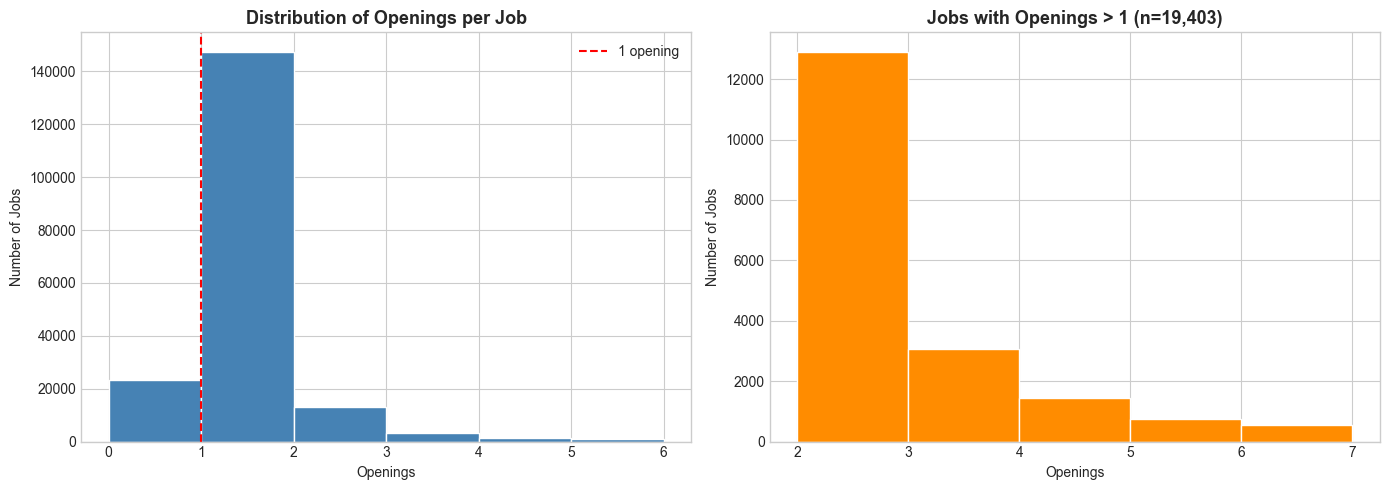


═══ Openings Summary ═══
Total records: 190,056
Records with openings = 1: 147,424 (77.6%)
Records with openings > 1: 19,403 (10.2%)
Records with openings > 5: 1,200
Records with openings > 10: 262
Max openings: 999

Total DEMAND (sum of openings): 205,341
vs counting each record as 1: 190,056

⚠️  If openings matters, demand is 1.08x what previous models assumed!


In [37]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Openings column reality check
# If jobs have openings > 1, previous models undercounted demand
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
openings = df['openings'].fillna(1)
axes[0].hist(openings, bins=range(0, int(openings.quantile(0.99)) + 2), 
            color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Openings per Job', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Openings')
axes[0].set_ylabel('Number of Jobs')
axes[0].axvline(x=1, color='red', linestyle='--', label='1 opening')
axes[0].legend()

# Zoomed: openings > 1
multi = openings[openings > 1]
axes[1].hist(multi, bins=range(2, int(multi.quantile(0.95)) + 2), 
            color='darkorange', edgecolor='white')
axes[1].set_title(f'Jobs with Openings > 1 (n={len(multi):,})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Openings')
axes[1].set_ylabel('Number of Jobs')

plt.tight_layout()
plt.show()

print(f"\n═══ Openings Summary ═══")
print(f"Total records: {len(df):,}")
print(f"Records with openings = 1: {(openings == 1).sum():,} ({(openings == 1).mean()*100:.1f}%)")
print(f"Records with openings > 1: {(openings > 1).sum():,} ({(openings > 1).mean()*100:.1f}%)")
print(f"Records with openings > 5: {(openings > 5).sum():,}")
print(f"Records with openings > 10: {(openings > 10).sum():,}")
print(f"Max openings: {openings.max()}")
print(f"\nTotal DEMAND (sum of openings): {openings.sum():,.0f}")
print(f"vs counting each record as 1: {len(df):,}")
print(f"\n⚠️  If openings matters, demand is {openings.sum()/len(df):.2f}x what previous models assumed!")

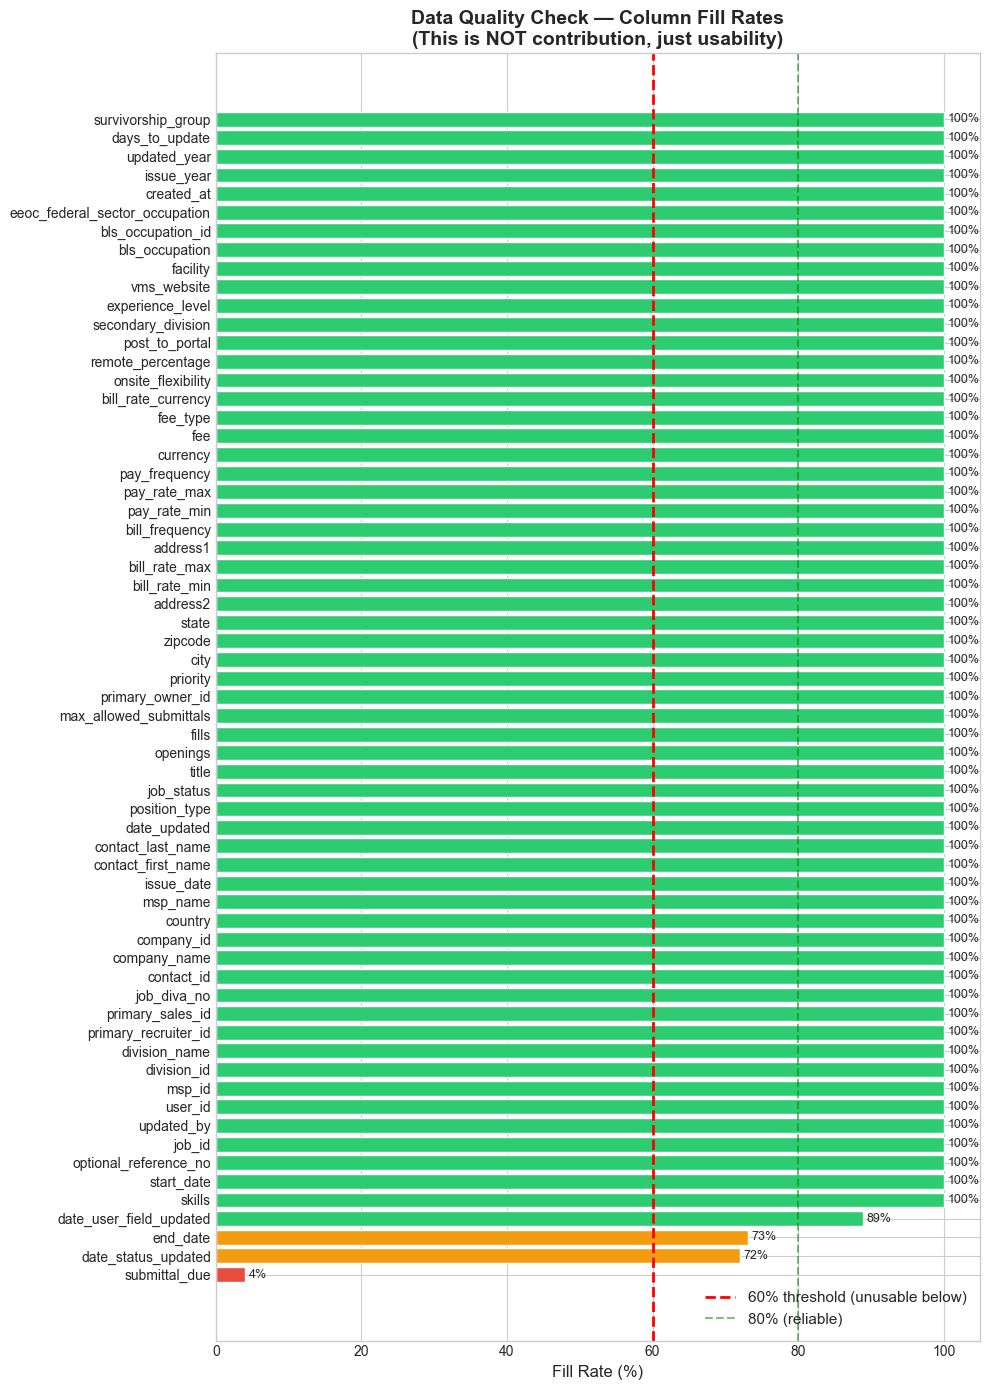


═══ Data Quality Summary (NOT Contribution) ═══
🟢 Green (≥80%): 60 columns — data available, MAY be useful
🟡 Yellow (60-80%): 2 columns — usable with imputation
🔴 Red (<60%): 1 columns — too sparse to use as features

⚠️  NOTE: A column being 100% filled does NOT mean it predicts anything.
   position_type is 100% filled but nearly constant → zero contribution.
   Contribution is measured in Cell 13 (group divergence + lag correlation).


In [38]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Data Quality Check (NOT contribution)
# Fill rate tells us which columns are USABLE, not which contribute.
# Anything below 60% can't be a reliable model feature.
# ═══════════════════════════════════════════════════════════════
fill_rates = ((df.notna().sum() / len(df)) * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))

colors = ['#2ecc71' if v >= 80 else '#f39c12' if v >= 60 else '#e74c3c' 
          for v in fill_rates.values]

bars = ax.barh(fill_rates.index, fill_rates.values, color=colors, edgecolor='white')
ax.axvline(x=60, color='red', linestyle='--', linewidth=2, label='60% threshold (unusable below)')
ax.axvline(x=80, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='80% (reliable)')

ax.set_xlabel('Fill Rate (%)', fontsize=12)
ax.set_title('Data Quality Check — Column Fill Rates\n(This is NOT contribution, just usability)', 
            fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)

# Add % labels
for bar, val in zip(bars, fill_rates.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n═══ Data Quality Summary (NOT Contribution) ═══")
print(f"🟢 Green (≥80%): {(fill_rates >= 80).sum()} columns — data available, MAY be useful")
print(f"🟡 Yellow (60-80%): {((fill_rates >= 60) & (fill_rates < 80)).sum()} columns — usable with imputation")
print(f"🔴 Red (<60%): {(fill_rates < 60).sum()} columns — too sparse to use as features")
print(f"\n⚠️  NOTE: A column being 100% filled does NOT mean it predicts anything.")
print(f"   position_type is 100% filled but nearly constant → zero contribution.")
print(f"   Contribution is measured in Cell 13 (group divergence + lag correlation).")

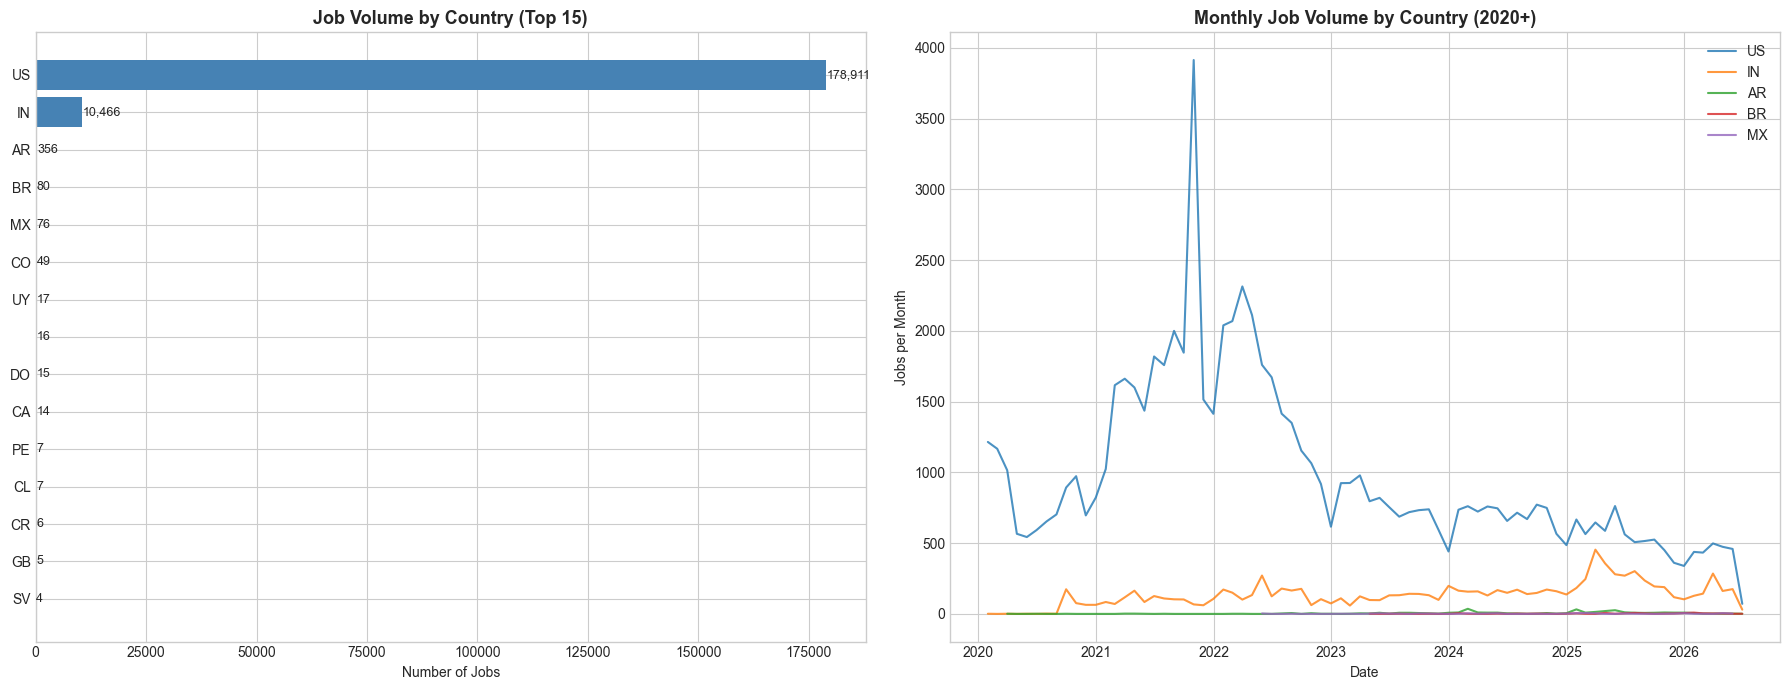


═══ Country Analysis ═══
Total countries: 28
US share: 94.1%

→ If country lines move INDEPENDENTLY → use separate models per country
→ If they're CORRELATED → country becomes a feature in one model


In [39]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Country distribution + pattern comparison
# Bar chart: count per country
# Line chart: monthly volume per country (top 5)
# ═══════════════════════════════════════════════════════════════
df['country_clean'] = df['country'].fillna('UNKNOWN').str.strip().str.upper()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart: records per country
country_counts = df['country_clean'].value_counts().head(15)
axes[0].barh(country_counts.index, country_counts.values, color='steelblue')
axes[0].set_title('Job Volume by Country (Top 15)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Jobs')
axes[0].invert_yaxis()
for i, (idx, val) in enumerate(country_counts.items()):
    axes[0].text(val + 100, i, f'{val:,}', va='center', fontsize=9)

# Line chart: monthly volume per top 5 countries
top5_countries = df['country_clean'].value_counts().head(5).index.tolist()
recent = df[df['issue_date'] >= '2020-01-01']  # Focus on recent years

for country in top5_countries:
    country_data = recent[recent['country_clean'] == country]
    monthly = country_data.set_index('issue_date').resample('ME').size()
    axes[1].plot(monthly.index, monthly.values, label=country, linewidth=1.5, alpha=0.8)

axes[1].set_title('Monthly Job Volume by Country (2020+)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Jobs per Month')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n═══ Country Analysis ═══")
print(f"Total countries: {df['country_clean'].nunique()}")
print(f"US share: {(df['country_clean']=='US').sum()/len(df)*100:.1f}%")
print(f"\n→ If country lines move INDEPENDENTLY → use separate models per country")
print(f"→ If they're CORRELATED → country becomes a feature in one model")

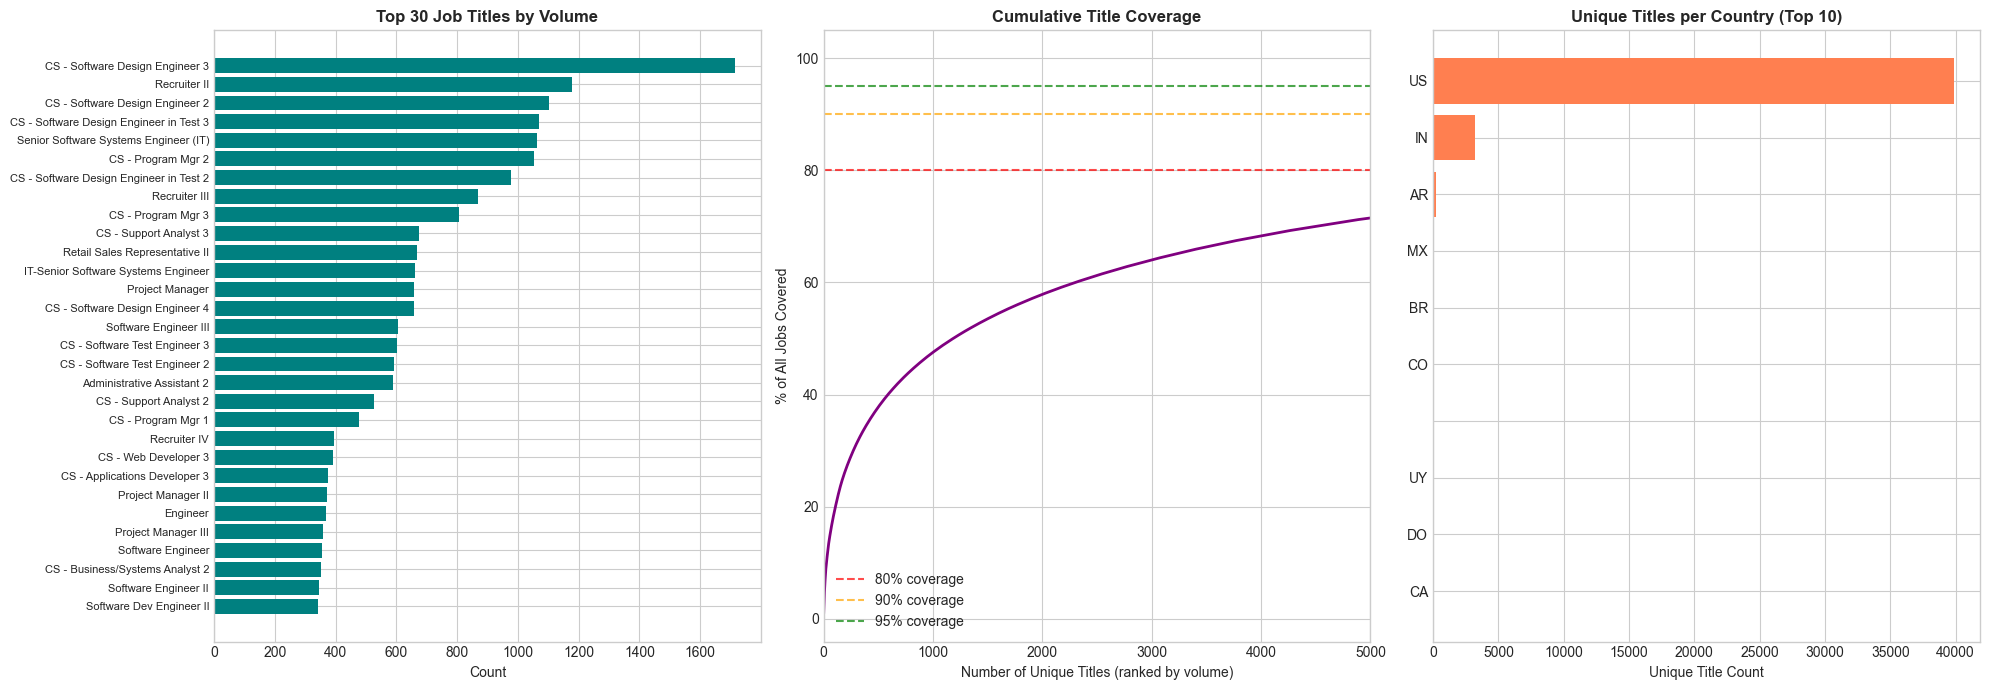


═══ Title Concentration ═══
Total unique titles: 42,414
Top 9,417 titles cover 80% of jobs
Top 23,409 titles cover 90% of jobs
Top 32,912 titles cover 95% of jobs

→ If 9417 titles cover 80%, clustering is ESSENTIAL
→ If LATAM has far fewer titles than US, clustering strategy differs per country


In [40]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Role title analysis
# Top 30 titles, cumulative coverage curve, unique titles per country
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Plot A: Top 30 titles by volume
title_counts = df['title'].value_counts().head(30)
axes[0].barh(title_counts.index, title_counts.values, color='teal')
axes[0].set_title('Top 30 Job Titles by Volume', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)

# Plot B: Cumulative coverage curve
all_titles = df['title'].value_counts()
cumulative = all_titles.cumsum() / all_titles.sum() * 100
axes[1].plot(range(1, len(cumulative) + 1), cumulative.values, color='purple', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% coverage')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% coverage')
axes[1].axhline(y=95, color='green', linestyle='--', alpha=0.7, label='95% coverage')
axes[1].set_title('Cumulative Title Coverage', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Unique Titles (ranked by volume)')
axes[1].set_ylabel('% of All Jobs Covered')
axes[1].legend()
axes[1].set_xlim(0, min(len(cumulative), 5000))

# Find coverage thresholds
titles_80 = (cumulative <= 80).sum() + 1
titles_90 = (cumulative <= 90).sum() + 1
titles_95 = (cumulative <= 95).sum() + 1

# Plot C: Unique titles per country (top 10 countries)
top10_countries = df['country_clean'].value_counts().head(10).index
titles_per_country = df[df['country_clean'].isin(top10_countries)].groupby('country_clean')['title'].nunique().sort_values(ascending=False)
axes[2].barh(titles_per_country.index, titles_per_country.values, color='coral')
axes[2].set_title('Unique Titles per Country (Top 10)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Unique Title Count')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n═══ Title Concentration ═══")
print(f"Total unique titles: {df['title'].nunique():,}")
print(f"Top {titles_80:,} titles cover 80% of jobs")
print(f"Top {titles_90:,} titles cover 90% of jobs")
print(f"Top {titles_95:,} titles cover 95% of jobs")
print(f"\n→ If {titles_80} titles cover 80%, clustering is ESSENTIAL")
print(f"→ If LATAM has far fewer titles than US, clustering strategy differs per country")

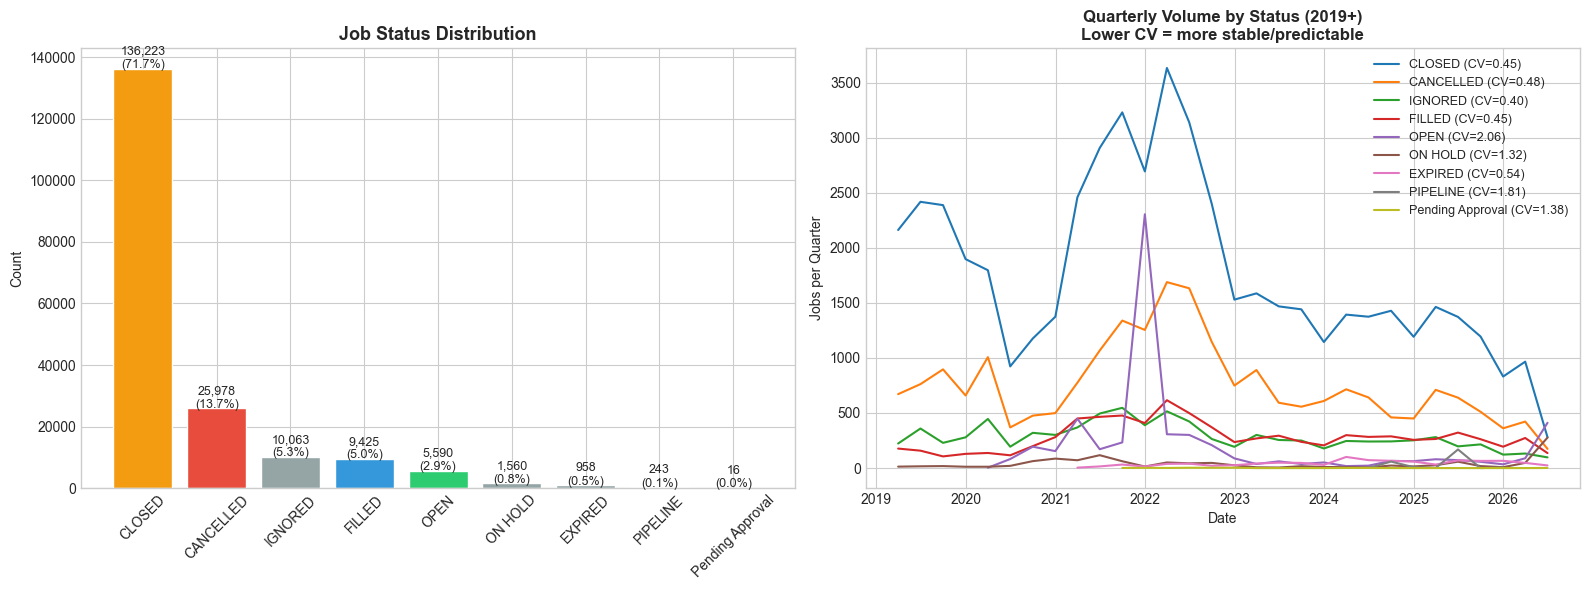


═══ Status Volatility Analysis ═══
Status          Count      Share    CV (volatility)    Signal Quality
─────────────────────────────────────────────────────────────────
CLOSED          136,223    71.7     0.449              🟡 Moderate
CANCELLED       25,978     13.7     0.481              🟡 Moderate
IGNORED         10,063     5.3      0.400              🟡 Moderate
FILLED          9,425      5.0      0.450              🟡 Moderate
OPEN            5,590      2.9      2.060              🔴 Volatile
ON HOLD         1,560      0.8      1.318              🔴 Volatile
EXPIRED         958        0.5      0.539              🟡 Moderate
PIPELINE        243        0.1      1.810              🔴 Volatile
Pending Approval 16         0.0      1.381              🔴 Volatile

→ Use statuses with LOW volatility (CV < 0.3) as your primary training signal.
→ High-volatility statuses add noise — they represent irregular events, not patterns.
→ The question isn't 'exclude CANCELLED?' — it's 'which statuses gi

In [41]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — job_status volatility analysis
# Question: Which status categories have stable vs volatile demand?
# This determines whether status is a useful filter for training data.
# ═══════════════════════════════════════════════════════════════
status_counts = df['job_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Status distribution
colors_status = {'OPEN': '#2ecc71', 'FILLED': '#3498db', 'CLOSED': '#f39c12', 
                 'CANCELLED': '#e74c3c', 'EXPIRED': '#95a5a6'}
bar_colors = [colors_status.get(s, '#95a5a6') for s in status_counts.index]
axes[0].bar(status_counts.index, status_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Job Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, (idx, val) in enumerate(status_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Plot B: Quarterly volatility (coefficient of variation) per status
# Higher CV = more volatile demand pattern = less predictable
recent = df[df['issue_date'] >= '2019-01-01']
volatility = {}
for status in status_counts.index:
    status_data = recent[recent['job_status'] == status]
    quarterly = status_data.set_index('issue_date').resample('QE').size()
    if len(quarterly) > 4 and quarterly.mean() > 0:
        cv = quarterly.std() / quarterly.mean()  # coefficient of variation
        volatility[status] = cv
        axes[1].plot(quarterly.index, quarterly.values, label=f'{status} (CV={cv:.2f})', linewidth=1.5)

axes[1].set_title('Quarterly Volume by Status (2019+)\nLower CV = more stable/predictable', 
                 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Jobs per Quarter')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Volatility summary
print("\n═══ Status Volatility Analysis ═══")
print(f"{'Status':<15} {'Count':<10} {'Share':<8} {'CV (volatility)':<18} {'Signal Quality'}")
print("─"*65)
for status in status_counts.index:
    count = status_counts[status]
    share = count / len(df) * 100
    cv = volatility.get(status, float('nan'))
    quality = '🟢 Stable' if cv < 0.3 else '🟡 Moderate' if cv < 0.6 else '🔴 Volatile'
    print(f"{status:<15} {count:<10,} {share:<8.1f} {cv:<18.3f} {quality}")

print(f"\n→ Use statuses with LOW volatility (CV < 0.3) as your primary training signal.")
print(f"→ High-volatility statuses add noise — they represent irregular events, not patterns.")
print(f"→ The question isn't 'exclude CANCELLED?' — it's 'which statuses give stable signal?'")

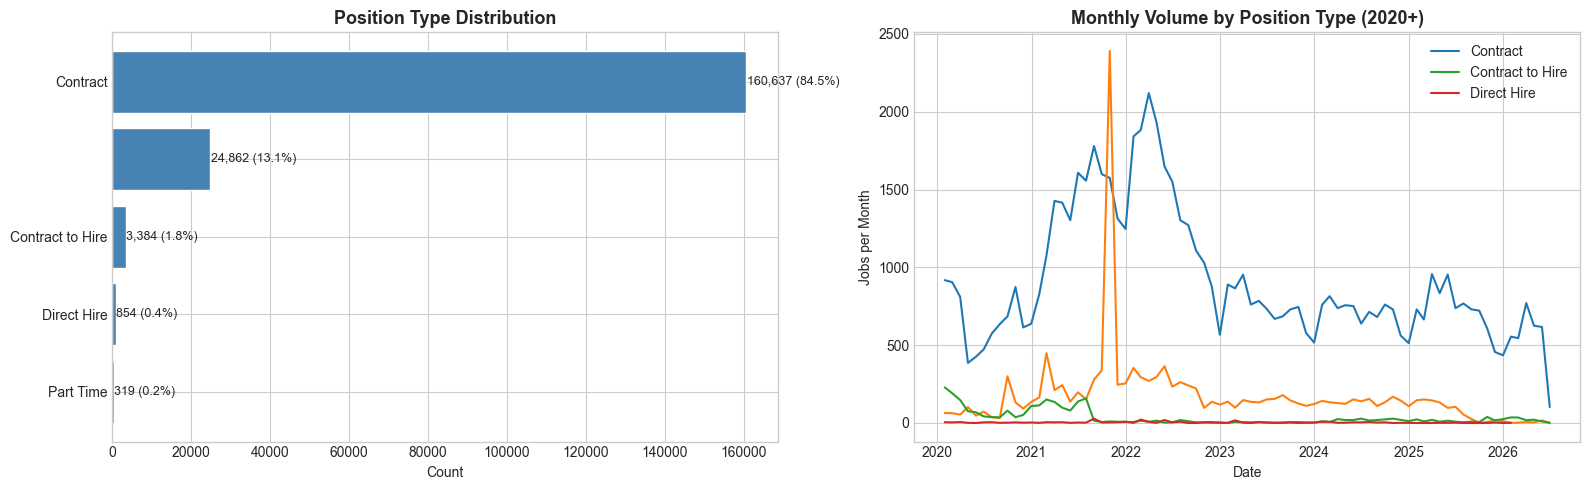


═══ Position Type Verdict ═══
Dominant type: Contract at 84.5%

⚠️  position_type has meaningful variance (85% dominant)
   → Check if Contract vs FTE have OPPOSITE seasonality (Cell 8 plot)
   → If opposite: model separately. If correlated: keep as feature.


In [42]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — position_type analysis
# For a staffing firm, this is almost certainly 90%+ Contract.
# If confirmed: drop as feature (constant columns add zero signal).
# ═══════════════════════════════════════════════════════════════
pos_types = df['position_type'].value_counts()
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
axes[0].barh(pos_types.index, pos_types.values, color='steelblue', edgecolor='white')
axes[0].set_title('Position Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()
for i, (idx, val) in enumerate(pos_types.items()):
    axes[0].text(val + 100, i, f'{val:,} ({val/total*100:.1f}%)', va='center', fontsize=9)

# Monthly volume by position type (top 4)
top_pos = pos_types.head(4).index.tolist()
recent = df[df['issue_date'] >= '2020-01-01']

for ptype in top_pos:
    pdata = recent[recent['position_type'] == ptype]
    monthly = pdata.set_index('issue_date').resample('ME').size()
    axes[1].plot(monthly.index, monthly.values, label=ptype, linewidth=1.5)

axes[1].set_title('Monthly Volume by Position Type (2020+)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Jobs per Month')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Definitive conclusion based on data
dominant_type = pos_types.index[0]
dominant_pct = pos_types.values[0] / total * 100

print(f"\n═══ Position Type Verdict ═══")
print(f"Dominant type: {dominant_type} at {dominant_pct:.1f}%")

if dominant_pct >= 85:
    print(f"\n❌ VERDICT: position_type is CONSTANT ({dominant_pct:.0f}% = '{dominant_type}')")
    print(f"   → DROP as a model feature. A column that's 85%+ one value adds zero signal.")
    print(f"   → Use as a filter note in output: 'Predictions apply to {dominant_type} roles.'")
    print(f"   → If you later want FTE predictions, build a separate model with FTE-only data.")
else:
    print(f"\n⚠️  position_type has meaningful variance ({dominant_pct:.0f}% dominant)")
    print(f"   → Check if Contract vs FTE have OPPOSITE seasonality (Cell 8 plot)")
    print(f"   → If opposite: model separately. If correlated: keep as feature.")

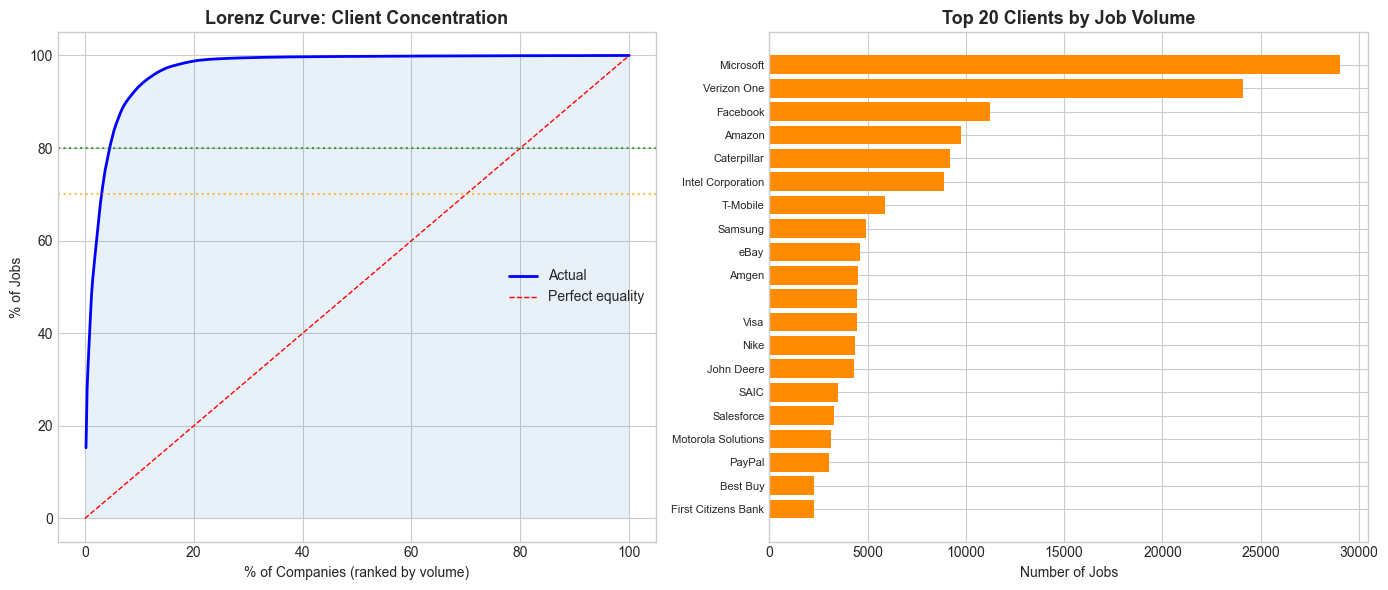


═══ Client Concentration ═══
Total unique companies: 488
Top 10 companies = 59.0% of all jobs
Top 20 companies = 77.4% of all jobs
Top 50 companies = 93.7% of all jobs

→ If top 10 = 70%+: company_name is a STRONG grouping feature
→ If top 50 < 50%: too fragmented, drop or bucket into 'Other'


In [43]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Company/Client concentration (Lorenz curve)
# If top 10 companies = 70% of jobs → company is a grouping feature
# If flat across hundreds → bucketing won't help, drop it
# ═══════════════════════════════════════════════════════════════
company_counts = df['company_name'].value_counts().sort_values(ascending=False)

# Lorenz curve
cumulative_jobs = company_counts.cumsum() / company_counts.sum() * 100
cumulative_companies = np.arange(1, len(company_counts) + 1) / len(company_counts) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lorenz curve
axes[0].plot(cumulative_companies, cumulative_jobs.values, 'b-', linewidth=2, label='Actual')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1, label='Perfect equality')
axes[0].axhline(y=70, color='orange', linestyle=':', alpha=0.7)
axes[0].axhline(y=80, color='green', linestyle=':', alpha=0.7)
axes[0].set_title('Lorenz Curve: Client Concentration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% of Companies (ranked by volume)')
axes[0].set_ylabel('% of Jobs')
axes[0].legend()
axes[0].fill_between(cumulative_companies, cumulative_jobs.values, alpha=0.1)

# Top 20 companies bar chart
top20 = company_counts.head(20)
axes[1].barh(top20.index, top20.values, color='darkorange')
axes[1].set_title('Top 20 Clients by Job Volume', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Jobs')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

# Key metrics
top10_pct = company_counts.head(10).sum() / company_counts.sum() * 100
top20_pct = company_counts.head(20).sum() / company_counts.sum() * 100
top50_pct = company_counts.head(50).sum() / company_counts.sum() * 100

print(f"\n═══ Client Concentration ═══")
print(f"Total unique companies: {len(company_counts):,}")
print(f"Top 10 companies = {top10_pct:.1f}% of all jobs")
print(f"Top 20 companies = {top20_pct:.1f}% of all jobs")
print(f"Top 50 companies = {top50_pct:.1f}% of all jobs")
print(f"\n→ If top 10 = 70%+: company_name is a STRONG grouping feature")
print(f"→ If top 50 < 50%: too fragmented, drop or bucket into 'Other'")

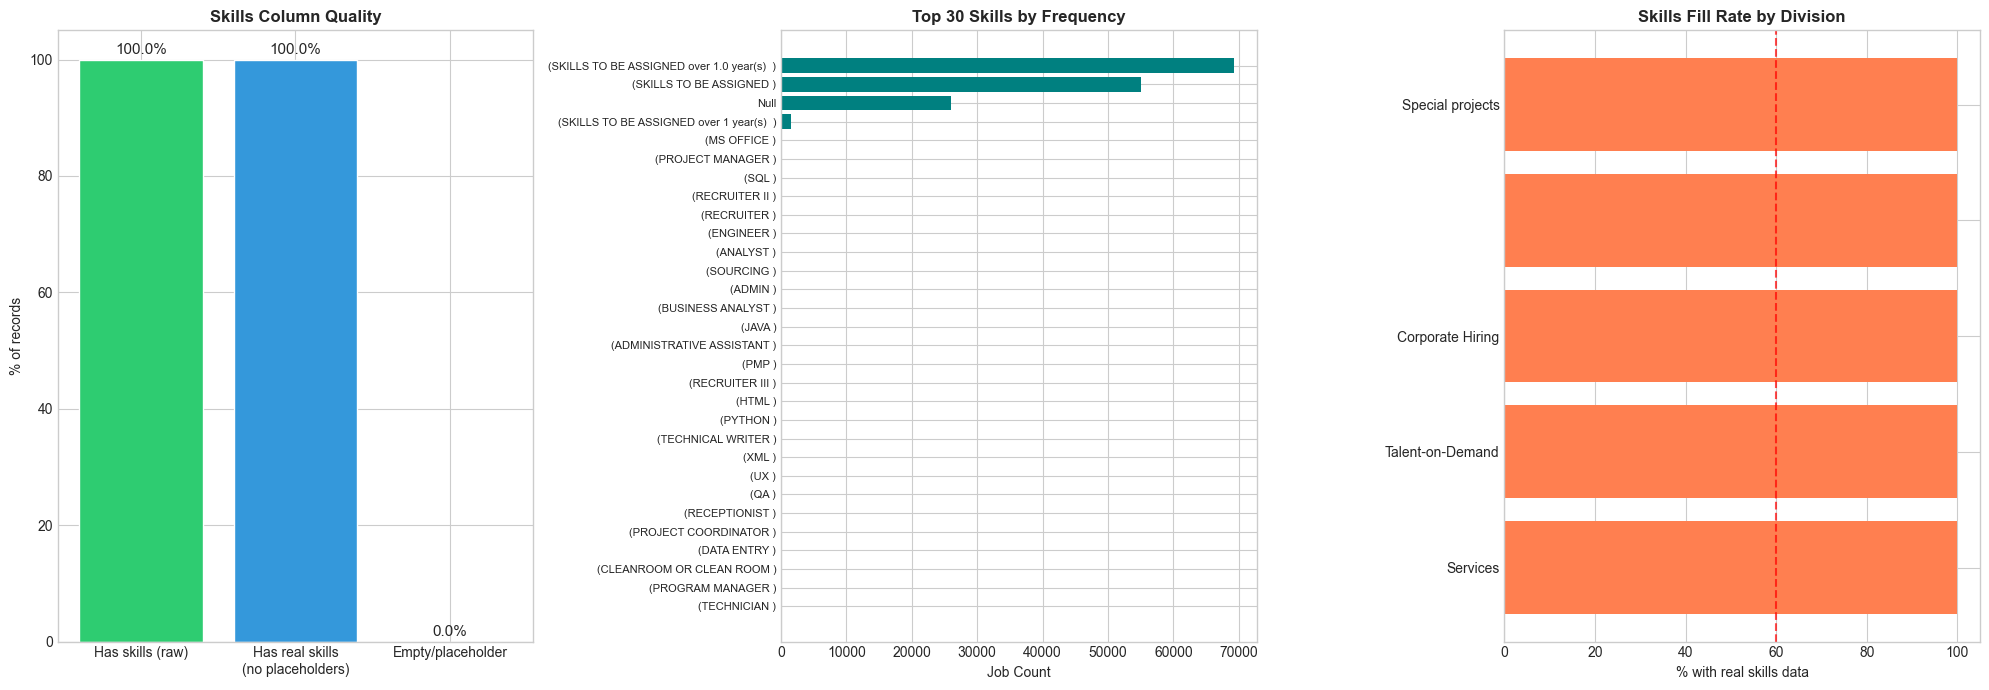


═══ Skills Analysis ═══
Total unique skills (cleaned): 33,395
Records with real skills: 190,052 (100.0%)

→ If skills fill > 60%: can be a feature for enrichment
→ Divisions with low fill: skills won't help predict those clusters


In [44]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Skills deep dive
# Fill rate after removing placeholders, top 30 skills, 
# skills coverage per division
# ═══════════════════════════════════════════════════════════════
# Clean skills — remove placeholder text
placeholders = ['SKILLS TO BE ASSIGNED', 'TBD', 'N/A', 'NA', 'NONE', '']
df['skills_raw'] = df['skills'].fillna('')
df['skills_clean'] = df['skills_raw'].apply(
    lambda x: x if x.strip().upper() not in placeholders else ''
)
df['has_real_skills'] = df['skills_clean'].str.len() > 3

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Plot A: Skills fill rate
skills_fill = pd.Series({
    'Has skills (raw)': df['skills'].notna().mean() * 100,
    'Has real skills\n(no placeholders)': df['has_real_skills'].mean() * 100,
    'Empty/placeholder': (~df['has_real_skills']).mean() * 100
})
axes[0].bar(skills_fill.index, skills_fill.values, 
           color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Skills Column Quality', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% of records')
for i, v in enumerate(skills_fill.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

# Plot B: Top 30 skills
all_skills = df[df['has_real_skills']]['skills_clean'].str.split(',').explode().str.strip()
all_skills = all_skills[all_skills.str.len() > 1]
top30_skills = all_skills.value_counts().head(30)
axes[1].barh(top30_skills.index, top30_skills.values, color='teal')
axes[1].set_title('Top 30 Skills by Frequency', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Job Count')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)

# Plot C: Skills fill rate per division (top 10 divisions)
top_divs = df['division_name'].value_counts().head(10).index
div_skills = df[df['division_name'].isin(top_divs)].groupby('division_name')['has_real_skills'].mean() * 100
div_skills = div_skills.sort_values(ascending=True)
axes[2].barh(div_skills.index, div_skills.values, color='coral')
axes[2].axvline(x=60, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Skills Fill Rate by Division', fontsize=12, fontweight='bold')
axes[2].set_xlabel('% with real skills data')

plt.tight_layout()
plt.show()

print(f"\n═══ Skills Analysis ═══")
print(f"Total unique skills (cleaned): {all_skills.nunique():,}")
print(f"Records with real skills: {df['has_real_skills'].sum():,} ({df['has_real_skills'].mean()*100:.1f}%)")
print(f"\n→ If skills fill > 60%: can be a feature for enrichment")
print(f"→ Divisions with low fill: skills won't help predict those clusters")

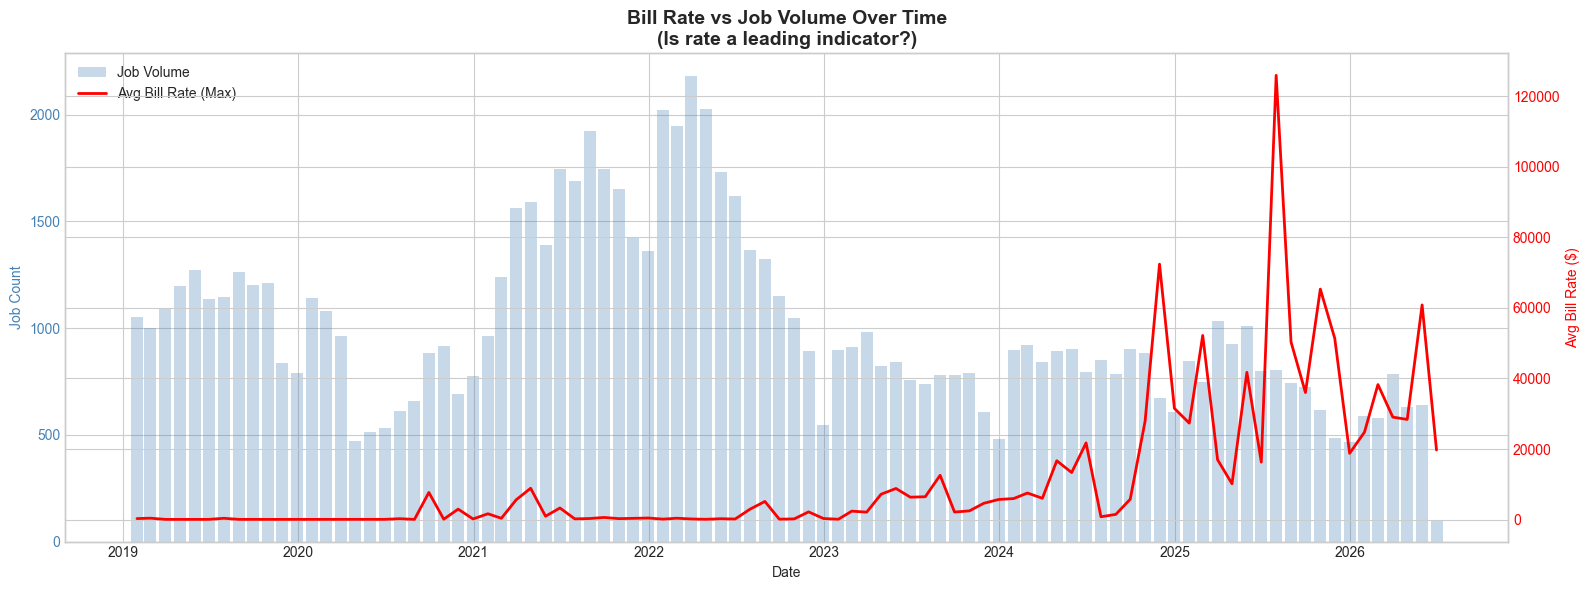


═══ Bill Rate as Leading Indicator ═══
Records with bill_rate_max: 190,056 (100.0%)

Lag correlation (rate → volume):
  Lag 0 months: r=-0.356, p=0.0006 ✓
  Lag 1 months: r=-0.399, p=0.0001 ✓
  Lag 2 months: r=-0.354, p=0.0007 ✓
  Lag 3 months: r=-0.352, p=0.0008 ✓

→ If any lag shows r > 0.3 with p < 0.05: bill_rate is a LEADING INDICATOR
→ If all correlations are weak: bill_rate adds noise, drop it


In [45]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — bill_rate as a leading indicator
# If rates rise 1-2 quarters before volume → strong leading indicator
# If flat/noisy → drop it
# ═══════════════════════════════════════════════════════════════
# Focus on recent clean window with non-null bill rates
rate_df = df[(df['bill_rate_max'].notna()) & (df['bill_rate_max'] > 0) & 
             (df['issue_date'] >= '2019-01-01')].copy()

# Monthly aggregation: avg bill rate and job count
monthly_rate = rate_df.set_index('issue_date').resample('ME').agg(
    avg_rate=('bill_rate_max', 'mean'),
    job_count=('job_id', 'count')
).dropna()

fig, ax1 = plt.subplots(figsize=(16, 6))

# Job volume (bars)
ax1.bar(monthly_rate.index, monthly_rate['job_count'], alpha=0.3, 
        color='steelblue', label='Job Volume', width=25)
ax1.set_xlabel('Date')
ax1.set_ylabel('Job Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Avg bill rate (line on secondary axis)
ax2 = ax1.twinx()
ax2.plot(monthly_rate.index, monthly_rate['avg_rate'], 
         color='red', linewidth=2, label='Avg Bill Rate (Max)')
ax2.set_ylabel('Avg Bill Rate ($)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('Bill Rate vs Job Volume Over Time\n(Is rate a leading indicator?)', 
             fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Cross-correlation to check if rate leads volume
from scipy import stats

# Lag correlation: does rate at time t correlate with volume at t+lag?
print("\n═══ Bill Rate as Leading Indicator ═══")
print(f"Records with bill_rate_max: {df['bill_rate_max'].notna().sum():,} ({df['bill_rate_max'].notna().mean()*100:.1f}%)")
print(f"\nLag correlation (rate → volume):")
n = len(monthly_rate)
for lag in [0, 1, 2, 3]:
    if n > lag + 5:
        # Align arrays: rate from beginning, volume shifted by lag
        rate_series = monthly_rate['avg_rate'].iloc[:n - lag].values
        volume_series = monthly_rate['job_count'].iloc[lag:].values
        corr, pval = stats.pearsonr(rate_series, volume_series)
        sig = '✓' if pval < 0.05 else '✗'
        print(f"  Lag {lag} months: r={corr:.3f}, p={pval:.4f} {sig}")

print(f"\n→ If any lag shows r > 0.3 with p < 0.05: bill_rate is a LEADING INDICATOR")
print(f"→ If all correlations are weak: bill_rate adds noise, drop it")

In [46]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — REAL Contribution Analysis
# 
# The right way to measure contribution:
# 1. Categoricals: Do groups behave differently over time?
#    (If Contract and FTE have identical curves → no contribution)
# 2. Numerics: Lag correlation with job volume
#    (Does bill_rate at T predict volume at T+1?)
# 3. Gold standard: Ablation testing (once model exists)
# ═══════════════════════════════════════════════════════════════
from scipy import stats
from scipy.stats import kruskal

# ── Use clean window only (post-2019, survivorship-clean) ──
clean_df = df[(df['issue_date'] >= '2019-01-01')].copy()
clean_df['month_period'] = clean_df['issue_date'].dt.to_period('M')

# Total monthly volume as baseline
total_monthly = clean_df.groupby('month_period').size()

print("═"*70)
print("REAL CONTRIBUTION ANALYSIS")
print("═"*70)
print("\nMethod: For each categorical column, we measure how DIFFERENTLY")
print("its groups behave over time. High divergence = high contribution.\n")

# ══════════════════════════════════════════════════════════════
# PART 1: Categorical Group-Behavior Divergence
# For each categorical: compute monthly time series per group,
# then measure coefficient of variation across group growth rates
# ══════════════════════════════════════════════════════════════
cat_columns = {
    'country': 'country_clean',  # already cleaned
    'company_name': 'company_name',
    'division_name': 'division_name',
    'position_type': 'position_type',
    'job_status': 'job_status',
}

divergence_scores = {}

for label, col in cat_columns.items():
    if col not in clean_df.columns:
        continue
    
    # Get top groups (enough volume to be meaningful)
    top_groups = clean_df[col].value_counts().head(8).index.tolist()
    group_series = {}
    
    for grp in top_groups:
        grp_monthly = clean_df[clean_df[col] == grp].groupby('month_period').size()
        if len(grp_monthly) > 12:  # need at least 12 months
            # Normalize to % of that group's mean (so we compare shapes, not magnitudes)
            group_series[grp] = grp_monthly / grp_monthly.mean()
    
    if len(group_series) < 2:
        divergence_scores[label] = 0
        continue
    
    # Align all series to same time index
    aligned = pd.DataFrame(group_series).dropna()
    
    if len(aligned) < 12:
        divergence_scores[label] = 0
        continue
    
    # Measure: standard deviation of correlations between groups
    # If all groups correlate highly → they move together → low divergence
    # If groups are uncorrelated → they move independently → HIGH divergence
    corrs = aligned.corr().values
    # Get upper triangle (excluding diagonal)
    upper = corrs[np.triu_indices_from(corrs, k=1)]
    
    # Divergence = 1 - mean_correlation (low correlation = high divergence)
    mean_corr = np.mean(upper)
    divergence = 1 - mean_corr
    divergence_scores[label] = round(divergence * 100, 1)

# ══════════════════════════════════════════════════════════════
# PART 2: Numeric Lag Correlation with Volume
# ══════════════════════════════════════════════════════════════
numeric_columns = ['bill_rate_max', 'openings', 'fills']
lag_scores = {}

for col in numeric_columns:
    col_df = clean_df[clean_df[col].notna() & (clean_df[col] > 0)]
    if len(col_df) < 100:
        lag_scores[col] = 0
        continue
    
    monthly_metric = col_df.set_index('issue_date').resample('ME')[col].mean().dropna()
    monthly_volume = clean_df.set_index('issue_date').resample('ME').size()
    
    # Align
    aligned_idx = monthly_metric.index.intersection(monthly_volume.index)
    if len(aligned_idx) < 12:
        lag_scores[col] = 0
        continue
    
    metric = monthly_metric.loc[aligned_idx].values
    volume = monthly_volume.loc[aligned_idx].values
    
    # Best lag correlation (0-3 months)
    best_corr = 0
    best_lag = 0
    for lag in [0, 1, 2, 3]:
        if len(metric) > lag + 5:
            r, p = stats.pearsonr(metric[:len(metric)-lag] if lag > 0 else metric,
                                  volume[lag:] if lag > 0 else volume)
            if abs(r) > abs(best_corr) and p < 0.1:
                best_corr = r
                best_lag = lag
    
    lag_scores[col] = round(abs(best_corr) * 100, 1)

# ══════════════════════════════════════════════════════════════
# PART 3: Combined Results
# ══════════════════════════════════════════════════════════════
print("\n" + "─"*70)
print("CATEGORICAL COLUMNS — Group Behavior Divergence")
print("─"*70)
print(f"{'Column':<20} {'Divergence':<15} {'Interpretation'}")
print("─"*70)

sorted_div = sorted(divergence_scores.items(), key=lambda x: x[1], reverse=True)
for col, score in sorted_div:
    if score > 30:
        interp = "🟢 HIGH — groups behave very differently → STRONG predictor"
    elif score > 15:
        interp = "🟡 MODERATE — some group differences → useful feature"
    else:
        interp = "🔴 LOW — groups move together → contributes little"
    print(f"{col:<20} {score:<15.1f} {interp}")

print(f"\n" + "─"*70)
print("NUMERIC COLUMNS — Lag Correlation with Job Volume")
print("─"*70)
print(f"{'Column':<20} {'|Correlation|':<15} {'Interpretation'}")
print("─"*70)

for col, score in lag_scores.items():
    if score > 30:
        interp = "🟢 STRONG leading indicator"
    elif score > 15:
        interp = "🟡 MODERATE signal"
    else:
        interp = "🔴 WEAK/NO signal — noise"
    print(f"{col:<20} {score:<15.1f} {interp}")

# ══════════════════════════════════════════════════════════════
# PART 4: Final Verdict
# ══════════════════════════════════════════════════════════════
print(f"\n" + "═"*70)
print("CONTRIBUTION VERDICT (based on actual predictive signal)")
print("═"*70)

all_scores = {**{k: v for k, v in divergence_scores.items()}, 
              **{k: v for k, v in lag_scores.items()}}
sorted_all = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)

keep = [k for k, v in sorted_all if v > 20]
maybe = [k for k, v in sorted_all if 10 <= v <= 20]
drop = [k for k, v in sorted_all if v < 10]

print(f"\n✅ KEEP (divergence > 20%): {', '.join(keep) if keep else 'none'}")
print(f"⚠️  MAYBE (10-20%): {', '.join(maybe) if maybe else 'none'}")
print(f"❌ DROP (< 10%): {', '.join(drop) if drop else 'none'}")
print(f"\n📌 NOTE: Final confirmation via ABLATION TESTING once model is built.")
print(f"   (Train with/without each feature → measure MAPE difference)")

══════════════════════════════════════════════════════════════════════
REAL CONTRIBUTION ANALYSIS
══════════════════════════════════════════════════════════════════════

Method: For each categorical column, we measure how DIFFERENTLY
its groups behave over time. High divergence = high contribution.


──────────────────────────────────────────────────────────────────────
CATEGORICAL COLUMNS — Group Behavior Divergence
──────────────────────────────────────────────────────────────────────
Column               Divergence      Interpretation
──────────────────────────────────────────────────────────────────────
division_name        96.3            🟢 HIGH — groups behave very differently → STRONG predictor
position_type        87.2            🟢 HIGH — groups behave very differently → STRONG predictor
job_status           76.9            🟢 HIGH — groups behave very differently → STRONG predictor
company_name         51.8            🟢 HIGH — groups behave very differently → STRONG predictor
c

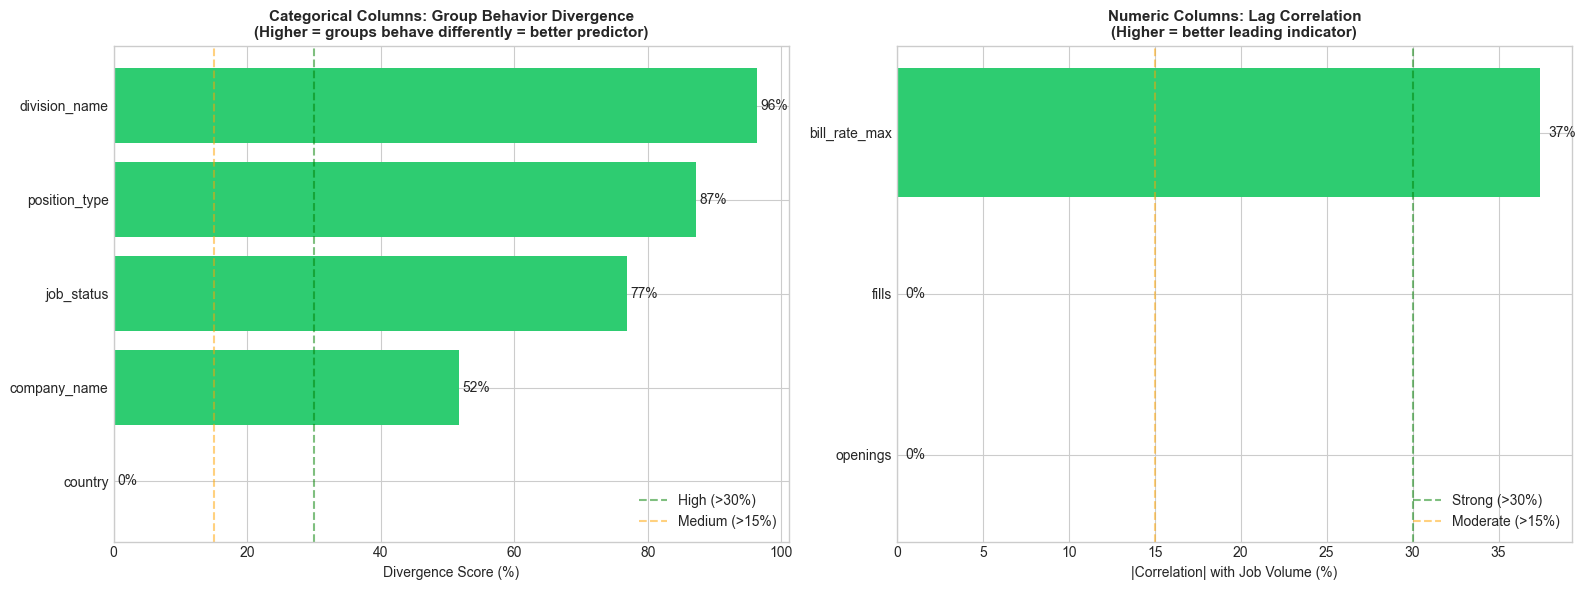


═══ What This Tells Us ═══
• Green bars = features that ACTUALLY differentiate job volume patterns
• Red bars = features that look the same across groups (no predictive value)
• This is the REAL contribution — not fill rates, not cardinality.


In [47]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — Contribution Visualization
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Categorical divergence scores
div_series = pd.Series(divergence_scores).sort_values(ascending=True)
colors_div = ['#2ecc71' if v > 30 else '#f39c12' if v > 15 else '#e74c3c' for v in div_series.values]
axes[0].barh(div_series.index, div_series.values, color=colors_div)
axes[0].axvline(x=30, color='green', linestyle='--', alpha=0.5, label='High (>30%)')
axes[0].axvline(x=15, color='orange', linestyle='--', alpha=0.5, label='Medium (>15%)')
axes[0].set_xlabel('Divergence Score (%)')
axes[0].set_title('Categorical Columns: Group Behavior Divergence\n(Higher = groups behave differently = better predictor)', 
                 fontsize=11, fontweight='bold')
axes[0].legend(loc='lower right')
for bar, val in zip(axes[0].patches, div_series.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)

# Plot B: Numeric lag correlation
lag_series = pd.Series(lag_scores).sort_values(ascending=True)
colors_lag = ['#2ecc71' if v > 30 else '#f39c12' if v > 15 else '#e74c3c' for v in lag_series.values]
axes[1].barh(lag_series.index, lag_series.values, color=colors_lag)
axes[1].axvline(x=30, color='green', linestyle='--', alpha=0.5, label='Strong (>30%)')
axes[1].axvline(x=15, color='orange', linestyle='--', alpha=0.5, label='Moderate (>15%)')
axes[1].set_xlabel('|Correlation| with Job Volume (%)')
axes[1].set_title('Numeric Columns: Lag Correlation\n(Higher = better leading indicator)', 
                 fontsize=11, fontweight='bold')
axes[1].legend(loc='lower right')
for bar, val in zip(axes[1].patches, lag_series.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n═══ What This Tells Us ═══")
print("• Green bars = features that ACTUALLY differentiate job volume patterns")
print("• Red bars = features that look the same across groups (no predictive value)")
print("• This is the REAL contribution — not fill rates, not cardinality.")

In [48]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — Training Window Validation
# 
# Three checks before finalizing ~57k training set:
# 1. Are 2019-2021 moderate_lag quarterly counts consistent or swiss-cheesed?
# 2. Do 2022+ moderate_lag records spread evenly across quarters?
# 3. Apply relaxed threshold (365 days for 2022+) and confirm final counts.
# ═══════════════════════════════════════════════════════════════

print("═"*70)
print("CHECK 1: 2019-2021 Moderate Lag — Quarterly Consistency")
print("═"*70)
print("If counts are relatively consistent → usable. If gaps/spikes → biased.\n")

window_2019 = df[
    (df['issue_date'] >= '2019-01-01') & 
    (df['issue_date'] < '2022-01-01') &
    (df['survivorship_group'] == 'moderate_lag')
]
quarterly_2019 = window_2019.groupby(window_2019['issue_date'].dt.to_period('Q')).size()
print(quarterly_2019)

# Consistency metrics
q_mean = quarterly_2019.mean()
q_std = quarterly_2019.std()
q_cv = q_std / q_mean if q_mean > 0 else float('inf')
q_min = quarterly_2019.min()
q_max = quarterly_2019.max()

print(f"\nMean: {q_mean:.0f} | Std: {q_std:.0f} | CV: {q_cv:.2f}")
print(f"Min: {q_min} | Max: {q_max} | Range ratio: {q_max/q_min:.1f}x")

if q_cv < 0.4:
    print("✅ CONSISTENT — quarterly counts are stable, these records are usable.")
elif q_cv < 0.6:
    print("⚠️  MODERATE VARIATION — check for specific gap quarters before including.")
else:
    print("❌ IRREGULAR — swiss-cheesed, these records may still be biased.")

print(f"\n{'═'*70}")
print("CHECK 2: 2022+ Moderate Lag — Issue Date Spread")
print("═"*70)
print("These are the 25k records we recover by relaxing threshold to 365 days.")
print("Verify they spread across quarters, not concentrated in one sweep period.\n")

window_2022 = df[
    (df['issue_date'] >= '2022-01-01') &
    (df['survivorship_group'] == 'moderate_lag')
]
quarterly_2022 = window_2022.groupby(window_2022['issue_date'].dt.to_period('Q')).size()
print(quarterly_2022)

q2_mean = quarterly_2022.mean()
q2_std = quarterly_2022.std()
q2_cv = q2_std / q2_mean if q2_mean > 0 else float('inf')

print(f"\nMean: {q2_mean:.0f} | Std: {q2_std:.0f} | CV: {q2_cv:.2f}")
print(f"Min: {quarterly_2022.min()} | Max: {quarterly_2022.max()}")

if q2_cv < 0.4:
    print("✅ WELL SPREAD — issue dates distributed evenly, safe to recover.")
elif q2_cv < 0.6:
    print("⚠️  SOMEWHAT UNEVEN — still usable but watch for concentration.")
else:
    print("❌ CONCENTRATED — issue dates clustered, may reflect sweep timing not real demand.")

# Also check: what does date_status_updated look like for these?
print(f"\ndate_status_updated distribution for 2022+ moderate_lag:")
status_updated_q = window_2022.groupby(window_2022['date_status_updated'].dt.to_period('Q')).size()
print(status_updated_q.tail(10))
print("(If clustered in 1-2 quarters → confirms mass sweep, but issue_date spread is what matters)")

print(f"\n{'═'*70}")
print("CHECK 3: Apply Updated Survivorship Threshold")
print("═"*70)
print("New rule: 365 days for records issued 2022+, keep 180 for pre-2022.\n")

# Apply relaxed threshold
df['survivorship_v2'] = np.where(
    df['days_to_update'].isna(), 'no_update_date',
    np.where(
        # Post-2022: relax to 365 days
        (df['issue_date'] >= '2022-01-01') & (df['days_to_update'] <= 365), 'clean',
        np.where(
            # Pre-2022: keep strict 180 days
            (df['issue_date'] < '2022-01-01') & (df['days_to_update'] <= 180), 'clean',
            np.where(df['days_to_update'] <= 730, 'moderate_lag', 'survivorship_artifact')
        )
    )
)

print("Updated survivorship groups (v2):")
print(df['survivorship_v2'].value_counts())

# Training set = clean_v2 + (2019-2021 moderate_lag IF check 1 passed)
clean_v2 = df[df['survivorship_v2'] == 'clean']
print(f"\n── Training Foundation (v2 clean): {len(clean_v2):,} records ──")
print(f"Date range: {clean_v2['issue_date'].min().strftime('%Y-%m')} → {clean_v2['issue_date'].max().strftime('%Y-%m')}")
print(f"\nBy country:")
print(clean_v2['country_clean'].value_counts().head(5))

# If 2019-2021 moderate_lag passes check 1, add them
if q_cv < 0.5:
    extended_set = pd.concat([clean_v2, window_2019])
    print(f"\n── Extended Training Set (+ 2019-2021 moderate_lag): {len(extended_set):,} records ──")
    print(f"Date range: {extended_set['issue_date'].min().strftime('%Y-%m')} → {extended_set['issue_date'].max().strftime('%Y-%m')}")
    print(f"\nQuarterly volume (extended set):")
    ext_quarterly = extended_set.groupby(extended_set['issue_date'].dt.to_period('Q')).size()
    print(ext_quarterly.tail(20))
else:
    print(f"\n⚠️  2019-2021 moderate_lag EXCLUDED (CV={q_cv:.2f} > 0.5)")
    print(f"    Training set stays at {len(clean_v2):,} records.")

print(f"\n{'═'*70}")
print("SUMMARY")
print("═"*70)
print(f"Original clean (180d): {(df['survivorship_group']=='clean').sum():,}")
print(f"Updated clean (365d for 2022+): {len(clean_v2):,}")
print(f"Records recovered: {len(clean_v2) - (df['survivorship_group']=='clean').sum():,}")
if q_cv < 0.5:
    print(f"Extended with 2019-2021 moderate_lag: {len(extended_set):,}")
    print(f"\n→ Segmentation math: {len(extended_set):,} records ÷ (3 countries × 50 clusters × 20 quarters)")
    print(f"   = ~{len(extended_set) // (3*50*20)} records per segment per quarter (avg)")


══════════════════════════════════════════════════════════════════════
CHECK 1: 2019-2021 Moderate Lag — Quarterly Consistency
══════════════════════════════════════════════════════════════════════
If counts are relatively consistent → usable. If gaps/spikes → biased.

issue_date
2019Q1      25
2019Q2      35
2019Q3      15
2019Q4       3
2020Q1      22
2020Q2       6
2020Q3     182
2020Q4     206
2021Q1     268
2021Q2     339
2021Q3    4370
2021Q4    4031
Freq: Q-DEC, dtype: int64

Mean: 792 | Std: 1598 | CV: 2.02
Min: 3 | Max: 4370 | Range ratio: 1456.7x
❌ IRREGULAR — swiss-cheesed, these records may still be biased.

══════════════════════════════════════════════════════════════════════
CHECK 2: 2022+ Moderate Lag — Issue Date Spread
══════════════════════════════════════════════════════════════════════
These are the 25k records we recover by relaxing threshold to 365 days.
Verify they spread across quarters, not concentrated in one sweep period.

issue_date
2022Q1    5778
2022Q2   

In [49]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — Per-Title Volume Check (Pre-Clustering)
# 
# How many role groups per country are actually modelable?
# Using raw `title` here — clustering will consolidate these further.
# Threshold: >= 40 records total (~2/quarter over 20 quarters)
# ═══════════════════════════════════════════════════════════════

# clean_v2 already defined in Cell 15 (42k records, survivorship_v2 == 'clean')
print("═"*70)
print("ROLE VIABILITY CHECK — Per Country (using raw titles)")
print("═"*70)
print(f"Training set: {len(clean_v2):,} records")
print(f"Note: raw titles shown — clustering will CONSOLIDATE these,")
print(f"      so viable cluster count will be HIGHER than viable title count.\n")

for country in ['US', 'IN']:
    country_data = clean_v2[clean_v2['country_clean'] == country]
    title_counts = country_data['title'].value_counts()
    
    print(f"\n{'─'*70}")
    print(f"{country} — {len(country_data):,} records, {title_counts.nunique():,} unique titles")
    print(f"{'─'*70}")
    
    print(f"\nTop 20 titles by volume:")
    for i, (title, count) in enumerate(title_counts.head(20).items(), 1):
        quarters_covered = country_data[country_data['title'] == title].groupby(
            country_data[country_data['title'] == title]['issue_date'].dt.to_period('Q')
        ).size()
        avg_per_q = count / max(len(quarters_covered), 1)
        print(f"  {i:2d}. {title[:50]:<50} {count:>5,} records  ({avg_per_q:.1f}/quarter)")
    
    # Viability thresholds
    viable_40 = (title_counts >= 40).sum()
    viable_80 = (title_counts >= 80).sum()
    viable_120 = (title_counts >= 120).sum()
    
    # What % of records do viable titles cover?
    records_in_viable = title_counts[title_counts >= 40].sum()
    coverage_pct = records_in_viable / len(country_data) * 100
    
    print(f"\n  Viability summary:")
    print(f"    Titles with >= 40 records (2/quarter):   {viable_40:>4} titles → covers {coverage_pct:.1f}% of {country} records")
    print(f"    Titles with >= 80 records (4/quarter):   {viable_80:>4} titles")
    print(f"    Titles with >= 120 records (6/quarter):  {viable_120:>4} titles")
    print(f"    Titles with < 40 records (thin):         {(title_counts < 40).sum():>4} titles ({(title_counts < 40).sum()/len(title_counts)*100:.0f}%)")

# Overall architecture guidance
print(f"\n{'═'*70}")
print("ARCHITECTURE IMPLICATIONS")
print("═"*70)

us_viable = (clean_v2[clean_v2['country_clean']=='US']['title'].value_counts() >= 40).sum()
in_viable = (clean_v2[clean_v2['country_clean']=='IN']['title'].value_counts() >= 40).sum()

print(f"\nModelable title groups: US={us_viable}, IN={in_viable}")
print(f"After clustering (consolidating similar titles), expect 1.5-2x these numbers.")
print(f"\n→ Design architecture around {us_viable} US clusters + {in_viable} IN clusters")
print(f"→ Thin titles (< 40 records) get rolled into 'Other-{'{category}'}' buckets")
print(f"→ AR/LATAM ({len(clean_v2[clean_v2['country_clean']=='AR']):,} records) — too thin for per-cluster models,")
print(f"   treat as single 'LATAM' segment with top 5-10 titles only")


══════════════════════════════════════════════════════════════════════
ROLE VIABILITY CHECK — Per Country (using raw titles)
══════════════════════════════════════════════════════════════════════
Training set: 42,016 records
Note: raw titles shown — clustering will CONSOLIDATE these,
      so viable cluster count will be HIGHER than viable title count.


──────────────────────────────────────────────────────────────────────
US — 33,222 records, 85 unique titles
──────────────────────────────────────────────────────────────────────

Top 20 titles by volume:
   1. Engineer                                             190 records  (11.9/quarter)
   2. Software Engineer III                                173 records  (10.2/quarter)
   3. Project and Program Management - Program Manager N   134 records  (10.3/quarter)
   4. Manufacturing Engineer II                            124 records  (13.8/quarter)
   5. Associate Scientist                                  119 records  (7.0/quarter)
   

══════════════════════════════════════════════════════════════════════
FEATURE CONTRIBUTION TO TARGET VARIABLE
══════════════════════════════════════════════════════════════════════

Target: quarterly job demand (count per quarter per country)
Dataset: 150 rows (quarter × country combinations)
Features tested against target:

  • country (encoded)       — does knowing the country predict demand?
  • avg_openings            — do more openings/job signal higher demand?
  • avg_bill_rate           — do rates correlate with volume?
  • n_titles (diversity)    — does title variety predict total demand?
  • n_companies (clients)   — does client count predict volume?
  • pct_with_skills         — does skills availability matter?
  • quarter_num (time)      — is there a time trend?

──────────────────────────────────────────────────────────────────────
METHOD 1: Mutual Information (non-linear dependency)
──────────────────────────────────────────────────────────────────────
Feature            

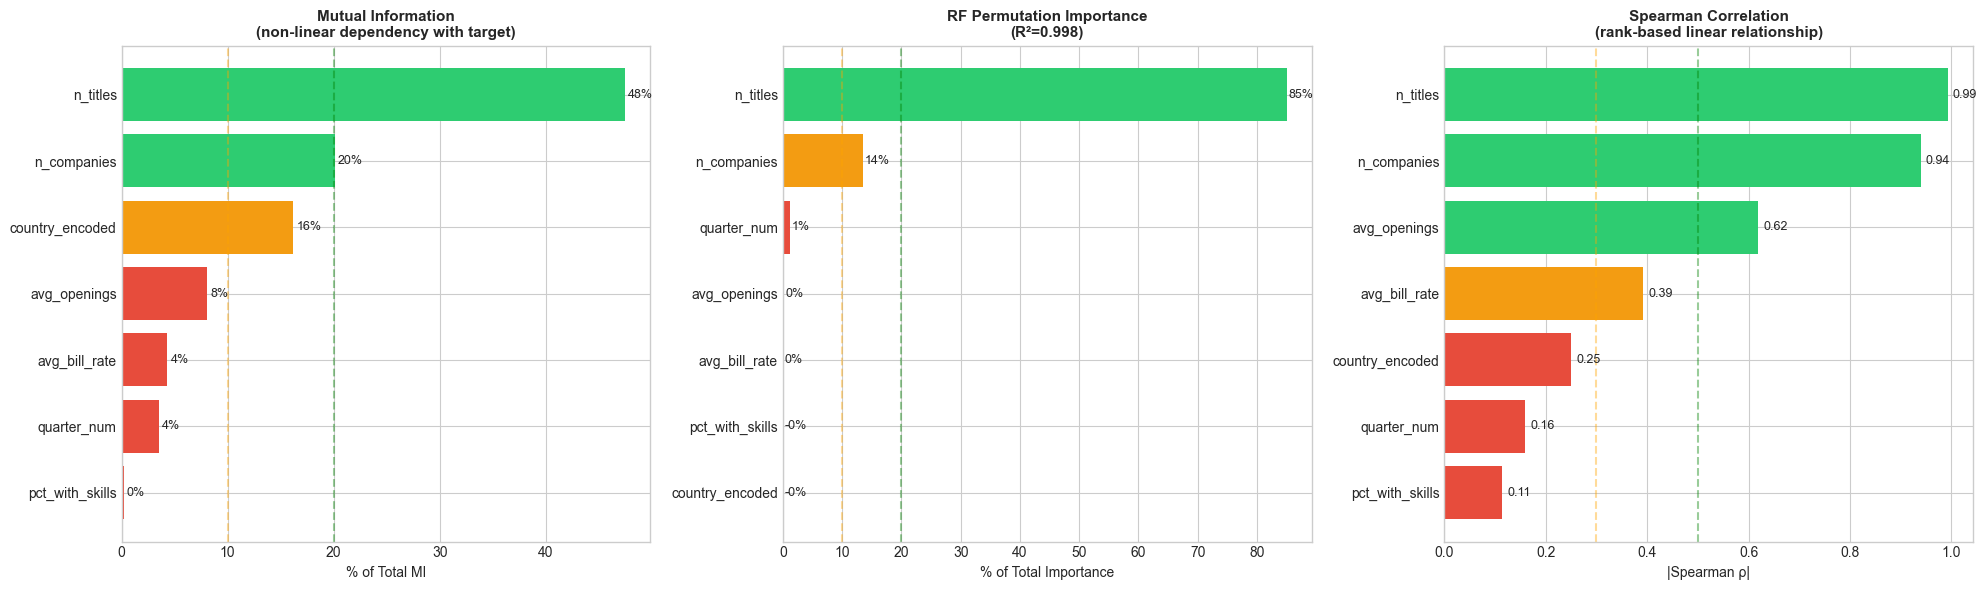


══════════════════════════════════════════════════════════════════════
FINAL RANKING: Feature Contribution to Target (Quarterly Demand)
══════════════════════════════════════════════════════════════════════

                 MI (%)  RF (%)  Spearman (×100)  COMBINED_SCORE
n_titles           47.5    85.0        99.333340            77.3
n_companies        20.1    13.5        93.960588            42.5
avg_openings        8.1     0.1        61.863090            23.4
avg_bill_rate       4.3     0.0        39.192326            14.5
country_encoded    16.2    -0.0        25.024325            13.7
quarter_num         3.5     1.2        15.916908             6.9
pct_with_skills     0.2    -0.0        11.409490             3.9

──────────────────────────────────────────────────────────────────────
VERDICT
──────────────────────────────────────────────────────────────────────

✅ TOP PREDICTORS of demand: n_titles, n_companies, avg_openings
❌ WEAK PREDICTORS: avg_bill_rate, country_encoded, quar

In [50]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — Feature Contribution to Target Variable
#
# Target: quarterly job demand (count of jobs per quarter per segment)
# Method: 
#   1. Mutual Information — non-linear dependency (feature → target)
#   2. Random Forest Feature Importance — permutation-based
#   3. Spearman Correlation — rank-based for numerics
#
# This answers: "If I know feature X, how much does that REDUCE
# my uncertainty about how many jobs will appear next quarter?"
# ═══════════════════════════════════════════════════════════════
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

# ── Build quarterly aggregated dataset from clean 42k ──
# This is the actual modeling granularity: demand per quarter per segment
train_df = clean_v2[clean_v2['issue_date'] >= '2019-01-01'].copy()
train_df['quarter'] = train_df['issue_date'].dt.to_period('Q')

# Aggregate: count jobs per (quarter × country × title × company)
# But first, build features at the quarterly level
quarterly_agg = train_df.groupby('quarter').agg(
    job_count=('job_id', 'count'),                    # TARGET
    n_countries=('country_clean', 'nunique'),          # how many countries active
    n_companies=('company_name', 'nunique'),           # how many clients active
    n_titles=('title', 'nunique'),                     # title diversity
    avg_openings=('openings', 'mean'),                 # avg openings per job
    avg_bill_rate=('bill_rate_max', 'mean'),           # avg rate
    pct_us=('country_clean', lambda x: (x == 'US').mean()),
    pct_contract=('position_type', lambda x: (x == 'Contract').mean()),
    pct_with_skills=('has_real_skills', 'mean'),       # skills fill rate
    n_unique_skills=('skills_clean', lambda x: x[x.str.len() > 3].nunique()),
).reset_index()

# Also build country-level quarterly features
country_quarterly = train_df.groupby(['quarter', 'country_clean']).agg(
    demand=('job_id', 'count'),
    avg_openings=('openings', 'mean'),
    avg_bill_rate=('bill_rate_max', 'mean'),
    n_titles=('title', 'nunique'),
    n_companies=('company_name', 'nunique'),
    pct_with_skills=('has_real_skills', 'mean'),
).reset_index()

# Encode country for the model
le_country = LabelEncoder()
country_quarterly['country_encoded'] = le_country.fit_transform(country_quarterly['country_clean'])
country_quarterly['quarter_num'] = country_quarterly['quarter'].apply(lambda x: x.year * 4 + x.quarter)

print("═"*70)
print("FEATURE CONTRIBUTION TO TARGET VARIABLE")
print("═"*70)
print(f"\nTarget: quarterly job demand (count per quarter per country)")
print(f"Dataset: {len(country_quarterly)} rows (quarter × country combinations)")
print(f"Features tested against target:\n")

# ── Define features and target ──
feature_cols = ['country_encoded', 'avg_openings', 'avg_bill_rate', 
                'n_titles', 'n_companies', 'pct_with_skills', 'quarter_num']
target_col = 'demand'

# Drop rows with NaN in features
model_df = country_quarterly[feature_cols + [target_col]].dropna()
X = model_df[feature_cols].values
y = model_df[target_col].values

print(f"  • country (encoded)       — does knowing the country predict demand?")
print(f"  • avg_openings            — do more openings/job signal higher demand?")
print(f"  • avg_bill_rate           — do rates correlate with volume?")
print(f"  • n_titles (diversity)    — does title variety predict total demand?")
print(f"  • n_companies (clients)   — does client count predict volume?")
print(f"  • pct_with_skills         — does skills availability matter?")
print(f"  • quarter_num (time)      — is there a time trend?")

# ══════════════════════════════════════════════════════════════
# METHOD 1: Mutual Information
# Measures non-linear statistical dependency with target
# Higher MI = more information about target contained in feature
# ══════════════════════════════════════════════════════════════
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_results = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# Normalize to percentages
mi_pct = (mi_results / mi_results.sum() * 100).round(1)

print(f"\n{'─'*70}")
print("METHOD 1: Mutual Information (non-linear dependency)")
print(f"{'─'*70}")
print(f"{'Feature':<25} {'MI Score':<12} {'% of Total':<12} {'Interpretation'}")
print(f"{'─'*70}")
for feat, score in mi_results.items():
    pct = mi_pct[feat]
    if pct > 20:
        interp = "🟢 STRONG — high info about target"
    elif pct > 10:
        interp = "🟡 MODERATE — useful signal"
    else:
        interp = "🔴 WEAK — little predictive info"
    print(f"{feat:<25} {score:<12.4f} {pct:<12.1f} {interp}")

# ══════════════════════════════════════════════════════════════
# METHOD 2: Random Forest Feature Importance (permutation)
# Train a quick RF, then measure how much shuffling each feature
# degrades prediction accuracy.
# ══════════════════════════════════════════════════════════════
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_score = rf.score(X, y)

# Permutation importance (more reliable than .feature_importances_)
perm_imp = permutation_importance(rf, X, y, n_repeats=20, random_state=42)
rf_results = pd.Series(perm_imp.importances_mean, index=feature_cols).sort_values(ascending=False)
rf_pct = (rf_results / rf_results.sum() * 100).round(1)

print(f"\n{'─'*70}")
print(f"METHOD 2: Random Forest Permutation Importance (R²={rf_score:.3f})")
print(f"{'─'*70}")
print(f"{'Feature':<25} {'Importance':<12} {'% of Total':<12} {'Interpretation'}")
print(f"{'─'*70}")
for feat, score in rf_results.items():
    pct = rf_pct[feat]
    if pct > 20:
        interp = "🟢 STRONG — model relies on this"
    elif pct > 10:
        interp = "🟡 MODERATE — contributes to accuracy"
    else:
        interp = "🔴 WEAK — model doesn't need this"
    print(f"{feat:<25} {score:<12.4f} {pct:<12.1f} {interp}")

# ══════════════════════════════════════════════════════════════
# METHOD 3: Spearman Rank Correlation (direct with target)
# ══════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

print(f"\n{'─'*70}")
print("METHOD 3: Spearman Rank Correlation with Demand")
print(f"{'─'*70}")
print(f"{'Feature':<25} {'ρ (rho)':<12} {'p-value':<12} {'Interpretation'}")
print(f"{'─'*70}")

spearman_results = {}
for i, feat in enumerate(feature_cols):
    rho, pval = spearmanr(X[:, i], y)
    spearman_results[feat] = abs(rho)
    sig = '✓' if pval < 0.05 else '✗'
    if abs(rho) > 0.5:
        interp = f"🟢 STRONG {sig}"
    elif abs(rho) > 0.3:
        interp = f"🟡 MODERATE {sig}"
    else:
        interp = f"🔴 WEAK {sig}"
    print(f"{feat:<25} {rho:<12.3f} {pval:<12.4f} {interp}")

# ══════════════════════════════════════════════════════════════
# COMBINED VISUALIZATION
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot A: Mutual Information
mi_sorted = mi_pct.sort_values(ascending=True)
colors_mi = ['#2ecc71' if v > 20 else '#f39c12' if v > 10 else '#e74c3c' for v in mi_sorted.values]
axes[0].barh(mi_sorted.index, mi_sorted.values, color=colors_mi)
axes[0].set_xlabel('% of Total MI')
axes[0].set_title('Mutual Information\n(non-linear dependency with target)', fontsize=11, fontweight='bold')
axes[0].axvline(x=20, color='green', linestyle='--', alpha=0.4)
axes[0].axvline(x=10, color='orange', linestyle='--', alpha=0.4)
for bar, val in zip(axes[0].patches, mi_sorted.values):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)

# Plot B: RF Permutation Importance
rf_sorted = rf_pct.sort_values(ascending=True)
colors_rf = ['#2ecc71' if v > 20 else '#f39c12' if v > 10 else '#e74c3c' for v in rf_sorted.values]
axes[1].barh(rf_sorted.index, rf_sorted.values, color=colors_rf)
axes[1].set_xlabel('% of Total Importance')
axes[1].set_title(f'RF Permutation Importance\n(R²={rf_score:.3f})', fontsize=11, fontweight='bold')
axes[1].axvline(x=20, color='green', linestyle='--', alpha=0.4)
axes[1].axvline(x=10, color='orange', linestyle='--', alpha=0.4)
for bar, val in zip(axes[1].patches, rf_sorted.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)

# Plot C: Spearman Correlation
sp_series = pd.Series(spearman_results).sort_values(ascending=True)
colors_sp = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.3 else '#e74c3c' for v in sp_series.values]
axes[2].barh(sp_series.index, sp_series.values, color=colors_sp)
axes[2].set_xlabel('|Spearman ρ|')
axes[2].set_title('Spearman Correlation\n(rank-based linear relationship)', fontsize=11, fontweight='bold')
axes[2].axvline(x=0.5, color='green', linestyle='--', alpha=0.4)
axes[2].axvline(x=0.3, color='orange', linestyle='--', alpha=0.4)
for bar, val in zip(axes[2].patches, sp_series.values):
    axes[2].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# FINAL VERDICT: Combined ranking
# ══════════════════════════════════════════════════════════════
# Normalize all three methods to 0-100 scale and average
combined = pd.DataFrame({
    'MI (%)': mi_pct,
    'RF (%)': rf_pct,
    'Spearman (×100)': pd.Series(spearman_results) * 100
})
combined['COMBINED_SCORE'] = combined.mean(axis=1).round(1)
combined = combined.sort_values('COMBINED_SCORE', ascending=False)

print(f"\n{'═'*70}")
print("FINAL RANKING: Feature Contribution to Target (Quarterly Demand)")
print(f"{'═'*70}")
print(f"\n{combined.to_string()}")

print(f"\n{'─'*70}")
print("VERDICT")
print(f"{'─'*70}")
top_features = combined[combined['COMBINED_SCORE'] > combined['COMBINED_SCORE'].median()].index.tolist()
weak_features = combined[combined['COMBINED_SCORE'] <= combined['COMBINED_SCORE'].median()].index.tolist()

print(f"\n✅ TOP PREDICTORS of demand: {', '.join(top_features)}")
print(f"❌ WEAK PREDICTORS: {', '.join(weak_features)}")
print(f"\n📌 Interpretation:")
print(f"   • Features that score HIGH across all 3 methods = robust predictors")
print(f"   • Features high in MI but low in Spearman = non-linear relationship")
print(f"   • Features high in RF only = interaction effects (combinations matter)")
print(f"   • quarter_num high = strong time trend (seasonality/growth)")
print(f"   • country high = countries have very different demand levels")


In [51]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 — Region Mapping: Club LATAM Countries Together
#
# Individual LATAM countries are too thin to model separately.
# AR=287, BR=75, MX=47 — but combined they become a viable segment.
# Final architecture: US | IN | LATAM (pooled)
# ═══════════════════════════════════════════════════════════════

# Define LATAM country codes (ISO 2-letter)
LATAM_COUNTRIES = {
    # Central America
    'MX', 'CR', 'SV', 'GT', 'HN', 'NI', 'PA',
    # South America
    'AR', 'BO', 'BR', 'CL', 'CO', 'EC', 'PY', 'PE', 'UY', 'VE',
    # Caribbean (Spanish/French speaking)
    'CU', 'DO', 'HT',
}

# Create region mapping
def map_region(country_code):
    if country_code == 'US':
        return 'US'
    elif country_code == 'IN':
        return 'IN'
    elif country_code in LATAM_COUNTRIES:
        return 'LATAM'
    else:
        return 'OTHER'

# Apply to full df and clean_v2
df['region'] = df['country_clean'].apply(map_region)
clean_v2 = df[df['survivorship_group'] == 'clean'].copy()
clean_v2['region'] = clean_v2['country_clean'].apply(map_region)

print("═"*70)
print("REGION MAPPING — LATAM Countries Clubbed Together")
print("═"*70)

# What LATAM countries actually exist in our data?
print("\n── LATAM countries found in clean_v2: ──")
latam_in_data = clean_v2[clean_v2['region'] == 'LATAM']['country_clean'].value_counts()
print(latam_in_data)
print(f"\nTotal LATAM records: {latam_in_data.sum():,}")

# Full region breakdown
print(f"\n── Region breakdown (clean 42k training set): ──")
region_counts = clean_v2['region'].value_counts()
print(region_counts)
print(f"\nRegion percentages:")
for region, count in region_counts.items():
    print(f"  {region:<8} {count:>7,} records ({count/len(clean_v2)*100:.1f}%)")

# Quarterly volume per region
print(f"\n── Quarterly volume per region (2022+): ──")
recent_clean = clean_v2[clean_v2['issue_date'] >= '2022-01-01']
region_quarterly = recent_clean.groupby([
    recent_clean['issue_date'].dt.to_period('Q'), 'region'
]).size().unstack(fill_value=0)
print(region_quarterly)

# LATAM viability check
print(f"\n── LATAM Viability Check: ──")
latam_data = clean_v2[clean_v2['region'] == 'LATAM']
latam_titles = latam_data['title'].value_counts()
print(f"Total LATAM records: {len(latam_data):,}")
print(f"Unique titles: {latam_titles.nunique()}")
print(f"Titles with >= 10 records: {(latam_titles >= 10).sum()}")
print(f"\nTop 10 LATAM titles:")
for i, (title, count) in enumerate(latam_titles.head(10).items(), 1):
    print(f"  {i:2d}. {title[:55]:<55} {count:>4} records")

# Architecture summary
print(f"\n{'═'*70}")
print("FINAL ARCHITECTURE — 3 Regions")
print("═"*70)
print(f"""
┌─────────┬──────────┬───────────────────────────────────────────┐
│ Region  │ Records  │ Strategy                                  │
├─────────┼──────────┼───────────────────────────────────────────┤
│ US      │ {region_counts.get('US', 0):>6,}  │ Per-cluster models (top 92 titles)        │
│ IN      │ {region_counts.get('IN', 0):>6,}  │ Per-cluster models (top 19 titles)        │
│ LATAM   │ {region_counts.get('LATAM', 0):>6,}  │ Pooled model, top 5-10 role clusters only │
│ OTHER   │ {region_counts.get('OTHER', 0):>6,}  │ Exclude or roll into nearest region       │
└─────────┴──────────┴───────────────────────────────────────────┘

Segmentation math (US):  {region_counts.get('US', 0):,} ÷ (92 clusters × 12 quarters) = ~{region_counts.get('US', 0) // (92*12)} per cluster/quarter
Segmentation math (IN):  {region_counts.get('IN', 0):,} ÷ (19 clusters × 12 quarters) = ~{region_counts.get('IN', 0) // (19*12)} per cluster/quarter
Segmentation math (LATAM): {region_counts.get('LATAM', 0):,} ÷ (5 clusters × 12 quarters) = ~{region_counts.get('LATAM', 0) // max((latam_titles >= 10).sum(), 1) // 12} per cluster/quarter
""")


══════════════════════════════════════════════════════════════════════
REGION MAPPING — LATAM Countries Clubbed Together
══════════════════════════════════════════════════════════════════════

── LATAM countries found in clean_v2: ──
country_clean
AR    287
BR     75
MX     47
CO     36
UY     11
DO     10
CR      6
CL      6
PE      5
SV      3
Name: count, dtype: int64

Total LATAM records: 486

── Region breakdown (clean 42k training set): ──
region
US       33222
IN        8256
LATAM      486
OTHER       52
Name: count, dtype: int64

Region percentages:
  US        33,222 records (79.1%)
  IN         8,256 records (19.6%)
  LATAM        486 records (1.2%)
  OTHER         52 records (0.1%)

── Quarterly volume per region (2022+): ──
region       IN  LATAM  OTHER    US
issue_date                         
2022Q1      254      0      0    32
2022Q2      360      0      0    21
2022Q3      397      0      0  2732
2022Q4      193      0      0  2206
2023Q1      275      0      0  2618
20

In [52]:
# ═══════════════════════════════════════════════════════════════
# Quick check: How many REAL clusters does LATAM actually have?
# Strip level prefixes (JR/SR/INT) and see what role families remain.
# ═══════════════════════════════════════════════════════════════
import re

latam_all = clean_v2[clean_v2['region'] == 'LATAM']['title'].value_counts()

print(f"ALL {len(latam_all)} unique LATAM titles ({latam_all.sum()} records):")
print("─"*70)
for title, count in latam_all.items():
    print(f"  {count:>4}  {title}")

# Naive clustering: strip common prefixes/suffixes
def normalize_title(t):
    t = t.strip()
    # Remove level prefixes
    t = re.sub(r'^(JR|Jr\.?|SR|Sr\.?|INT|Int\.?|SSR)\s+', '', t, flags=re.IGNORECASE)
    # Remove trailing level numbers
    t = re.sub(r'\s+(I|II|III|IV|V|1|2|3|4|5)$', '', t)
    # Remove trailing dash-level patterns
    t = re.sub(r'\s*-\s*(L[0-9]|Level\s*[0-9]|Junior|Senior|Mid|Lead)\s*$', '', t, flags=re.IGNORECASE)
    return t.strip()

latam_titles_raw = clean_v2[clean_v2['region'] == 'LATAM']['title'].copy()
latam_clusters = latam_titles_raw.apply(normalize_title).value_counts()

print(f"\n{'═'*70}")
print(f"After normalizing (strip JR/SR/INT prefixes): {len(latam_clusters)} clusters")
print("═"*70)
for cluster, count in latam_clusters.items():
    viable = "✓" if count >= 10 else "✗"
    print(f"  {viable} {count:>4}  {cluster}")

print(f"\n── Summary ──")
print(f"Total records: {latam_clusters.sum()}")
print(f"Clusters with >= 10 records: {(latam_clusters >= 10).sum()}")
print(f"Clusters with >= 20 records: {(latam_clusters >= 20).sum()}")
print(f"Clusters with >= 5 records:  {(latam_clusters >= 5).sum()}")
print(f"\n→ This is the REAL number of modelable LATAM clusters.")


ALL 312 unique LATAM titles (486 records):
──────────────────────────────────────────────────────────────────────
    16  JR Cloud Engineer
     9  SR Cloud Engineer
     9  SR Java Developer
     7  INT Frontend Developer
     6  SR QA Automation
     6  INT Java Developer
     6  Project Manager
     6  Sr Cloud Engineer
     6  Customer Helpdesk Specialist - L1 Support
     6  Jr. Cloud Engineer
     6  JR L1 Help Desk
     6  SR DevOps Engineer
     6  JR/INT L1 Help desk
     4  SR Manual QA
     4  SR Salesforce Developer
     4  Sr Java Developer
     4  QA Engineer
     4  INT L1 Help Desk
     4  SR Front End Developer
     4  SR Backend Developer
     3  SR Angular Developer
     3  INT/SR Manual QA
     3  Senior Manual QA
     3  Data Engineer
     3  Sr C++ Developer (PDS)
     3  INT Desarrollador BI
     3  JR Developer Python
     3  INT System Support Engineer
     2  SR Scrum Master
     2  SR Cloud Engineer L3
     2  Cloud Admin L1
     2  SR Software Architect
    

In [53]:
# Quick summary of LATAM cluster reality
print(f"LATAM cluster reality after normalizing titles:")
print(f"  Total unique raw titles: {len(latam_all)}")
print(f"  After stripping JR/SR/INT: {len(latam_clusters)} clusters")
print(f"  Clusters >= 20 records: {(latam_clusters >= 20).sum()}")
print(f"  Clusters >= 10 records: {(latam_clusters >= 10).sum()}")
print(f"  Clusters >= 5 records:  {(latam_clusters >= 5).sum()}")
print(f"\nTop clusters after normalization:")
for cluster, count in latam_clusters.head(15).items():
    print(f"  {count:>4}  {cluster}")


LATAM cluster reality after normalizing titles:
  Total unique raw titles: 312
  After stripping JR/SR/INT: 260 clusters
  Clusters >= 20 records: 2
  Clusters >= 10 records: 5
  Clusters >= 5 records:  14

Top clusters after normalization:
    38  Cloud Engineer
    22  Java Developer
    10  QA Automation
    10  L1 Help Desk
    10  DevOps Engineer
     8  Manual QA
     8  Frontend Developer
     7  Project Manager
     6  Angular Developer
     6  Front End Developer
     6  Customer Helpdesk Specialist - L1 Support
     6  JR/INT L1 Help desk
     5  Salesforce Developer
     5  QA Engineer
     4  Scrum Master


In [54]:
# ═══════════════════════════════════════════════════════════════
# State-level viability check
# Can we add state as a sub-segmentation for US?
# ═══════════════════════════════════════════════════════════════

# Check state column exists and fill rate
us_clean = clean_v2[clean_v2['country_clean'] == 'US']

print("═"*70)
print("STATE COLUMN VIABILITY — US Records")
print("═"*70)

# Fill rate
state_filled = us_clean['state'].notna() & (us_clean['state'].str.strip() != '')
print(f"\nUS clean records: {len(us_clean):,}")
print(f"State filled: {state_filled.sum():,} ({state_filled.mean()*100:.1f}%)")
print(f"State empty: {(~state_filled).sum():,}")

if state_filled.mean() > 0.5:
    # State distribution
    us_states = us_clean[state_filled]['state'].str.strip().str.upper().value_counts()
    
    print(f"\n── Top 20 US States by volume: ──")
    for i, (state, count) in enumerate(us_states.head(20).items(), 1):
        pct = count / state_filled.sum() * 100
        print(f"  {i:2d}. {state:<5} {count:>5,} records ({pct:.1f}%)")
    
    print(f"\n── State concentration: ──")
    print(f"Unique states: {us_states.nunique()}")
    print(f"Top 5 states cover: {us_states.head(5).sum()/state_filled.sum()*100:.1f}%")
    print(f"Top 10 states cover: {us_states.head(10).sum()/state_filled.sum()*100:.1f}%")
    
    # Viability: states with >= 40 records (modelable)
    viable_states = (us_states >= 40).sum()
    thin_states = (us_states < 40).sum()
    print(f"\nStates with >= 40 records: {viable_states} (modelable)")
    print(f"States with < 40 records: {thin_states} (roll into 'Other')")
    
    # How much does state ADD as info beyond country?
    # If top 5 states = 80%+ → state is concentrated → useful segmentation
    # If flat across 50 → too fragmented
    print(f"\n── Verdict: ──")
    top5_pct = us_states.head(5).sum()/state_filled.sum()*100
    if state_filled.mean() > 0.7 and viable_states >= 10:
        print(f"✅ State is VIABLE as sub-segmentation for US")
        print(f"   Fill rate: {state_filled.mean()*100:.0f}% | Viable states: {viable_states}")
        print(f"   → Add as: region(US) + state(CA/TX/WA/...) in model hierarchy")
    elif state_filled.mean() > 0.5:
        print(f"⚠️  State is PARTIALLY viable — {state_filled.mean()*100:.0f}% fill rate")
        print(f"   → Use for top {viable_states} states, bucket rest as 'US-Other'")
    else:
        print(f"❌ State fill too low ({state_filled.mean()*100:.0f}%) — can't rely on it")
else:
    print(f"\n❌ State fill rate too low ({state_filled.mean()*100:.1f}%) — not usable")
    print(f"   Would need to backfill from city/zipcode or job descriptions")

# Also check India (city might serve as "state" equivalent)
print(f"\n{'═'*70}")
print("CITY COLUMN — India (state equivalent)")
print("═"*70)
in_clean = clean_v2[clean_v2['country_clean'] == 'IN']
in_city_filled = in_clean['city'].notna() & (in_clean['city'].str.strip() != '')
print(f"India records: {len(in_clean):,}")
print(f"City filled: {in_city_filled.sum():,} ({in_city_filled.mean()*100:.1f}%)")
if in_city_filled.mean() > 0.3:
    in_cities = in_clean[in_city_filled]['city'].str.strip().value_counts()
    print(f"\nTop 10 India cities:")
    for city, count in in_cities.head(10).items():
        print(f"  {city:<25} {count:>5,}")


══════════════════════════════════════════════════════════════════════
STATE COLUMN VIABILITY — US Records
══════════════════════════════════════════════════════════════════════

US clean records: 33,222
State filled: 32,482 (97.8%)
State empty: 740

── Top 20 US States by volume: ──
   1. CA    7,655 records (23.6%)
   2. WA    5,117 records (15.8%)
   3. IL    3,350 records (10.3%)
   4. TX    2,638 records (8.1%)
   5. NJ    1,842 records (5.7%)
   6. NY    1,156 records (3.6%)
   7. IA    1,155 records (3.6%)
   8. NC      788 records (2.4%)
   9. MA      726 records (2.2%)
  10. GA      691 records (2.1%)
  11. OR      612 records (1.9%)
  12. OH      588 records (1.8%)
  13. FL      570 records (1.8%)
  14. AZ      539 records (1.7%)
  15. MN      508 records (1.6%)
  16. PA      420 records (1.3%)
  17. KS      419 records (1.3%)
  18. VA      402 records (1.2%)
  19. TN      348 records (1.1%)
  20. IN      294 records (0.9%)

── State concentration: ──
Unique states: 56
Top 5 

In [55]:
# ═══════════════════════════════════════════════════════════════
# CELL 22 — Unified `location` column
# Club state (US) + city (IN) into one geographic sub-segment.
# Merge Bangalore + Bengaluru (same city, two spellings).
# ═══════════════════════════════════════════════════════════════

# India city normalization map (merge duplicates)
INDIA_CITY_NORMALIZE = {
    'Bengaluru': 'Bangalore',
    'BENGALURU': 'Bangalore',
    'bengaluru': 'Bangalore',
    'BANGALORE': 'Bangalore',
    'HYDERABAD': 'Hyderabad',
    'PUNE': 'Pune',
    'CHENNAI': 'Chennai',
    'MUMBAI': 'Mumbai',
    'NOIDA': 'Noida',
}

def build_location(row):
    """Unified location: state for US, normalized city for IN, null for LATAM/OTHER."""
    region = row.get('region', '')
    
    if region == 'US':
        state = row.get('state', '')
        if pd.notna(state) and str(state).strip():
            return str(state).strip().upper()
        return None
    
    elif region == 'IN':
        city = row.get('city', '')
        if pd.notna(city) and str(city).strip():
            city_clean = str(city).strip().title()
            # Normalize known duplicates
            return INDIA_CITY_NORMALIZE.get(city_clean, city_clean)
        return None
    
    else:
        return None  # LATAM/OTHER — no sub-region needed

# Apply to clean_v2
clean_v2['location'] = clean_v2.apply(build_location, axis=1)

print("═"*70)
print("UNIFIED LOCATION COLUMN — State (US) + City (IN)")
print("═"*70)

# US summary
us_locs = clean_v2[clean_v2['region'] == 'US']['location']
us_filled = us_locs.notna().sum()
print(f"\n── US: state as location ──")
print(f"Filled: {us_filled:,} / {len(us_locs):,} ({us_filled/len(us_locs)*100:.1f}%)")
print(f"Top 5: {clean_v2[clean_v2['region']=='US']['location'].value_counts().head(5).to_dict()}")

# India summary (with Bangalore merge confirmed)
in_locs = clean_v2[clean_v2['region'] == 'IN']['location']
in_filled = in_locs.notna().sum()
print(f"\n── IN: city as location (Bangalore+Bengaluru merged) ──")
print(f"Filled: {in_filled:,} / {len(in_locs):,} ({in_filled/len(in_locs)*100:.1f}%)")
in_top = clean_v2[clean_v2['region']=='IN']['location'].value_counts().head(8)
for city, count in in_top.items():
    print(f"  {city:<20} {count:>5,}")

# LATAM (null — pooled)
latam_locs = clean_v2[clean_v2['region'] == 'LATAM']['location']
print(f"\n── LATAM: no sub-region (pooled) ──")
print(f"All null: {latam_locs.isna().sum():,} / {len(latam_locs):,}")

# Final feature schema
print(f"\n{'═'*70}")
print("FINAL FEATURE SCHEMA (7 columns)")
print("═"*70)
print(f"""
┌────┬─────────────────┬──────────────────────────────────────────────┐
│  # │ Column          │ Role                                         │
├────┼─────────────────┼──────────────────────────────────────────────┤
│  1 │ issue_date      │ Time dimension → quarter                     │
│  2 │ country         │ Region segmentation (US / IN / LATAM)        │
│  3 │ location        │ Sub-region: state(US), city(IN), null(LATAM) │
│  4 │ title           │ Role → clustering target                     │
│  5 │ company_name    │ Client grouping                              │
│  6 │ openings        │ Demand multiplier                            │
│  7 │ skills          │ Clustering enrichment                        │
├────┼─────────────────┼──────────────────────────────────────────────┤
│  T │ COUNT(*)        │ Target: demand per segment per quarter       │
└────┴─────────────────┴──────────────────────────────────────────────┘

Cleanup applied:
  • Bangalore + Bengaluru → merged as 'Bangalore' (~3,142 records)
  • US states: uppercased, stripped
  • LATAM: no location needed (pooled region)

→ Next: Title clustering strategy
""")


══════════════════════════════════════════════════════════════════════
UNIFIED LOCATION COLUMN — State (US) + City (IN)
══════════════════════════════════════════════════════════════════════

── US: state as location ──
Filled: 32,482 / 33,222 (97.8%)
Top 5: {'CA': 7655, 'WA': 5117, 'IL': 3350, 'TX': 2638, 'NJ': 1842}

── IN: city as location (Bangalore+Bengaluru merged) ──
Filled: 6,762 / 8,256 (81.9%)
  Bangalore            3,154
  Hyderabad            1,338
  Pune                   749
  Chennai                543
  Noida                  127
  Gurgaon                 80
  Pune, Bangalore         76
  Hyderabad Knowledge City    69

── LATAM: no sub-region (pooled) ──
All null: 486 / 486

══════════════════════════════════════════════════════════════════════
FINAL FEATURE SCHEMA (7 columns)
══════════════════════════════════════════════════════════════════════

┌────┬─────────────────┬──────────────────────────────────────────────┐
│  # │ Column          │ Role                      

In [56]:
# ═══════════════════════════════════════════════════════════════
# CELL 23 — India City Standardization
# Merge duplicate spellings, handle multi-city entries,
# then value_counts() to find remaining variants.
# ═══════════════════════════════════════════════════════════════

# Known duplicates / alternate spellings / compound entries
city_map = {
    'Bengaluru': 'Bangalore',
    'Bengaluru ': 'Bangalore',
    'BENGALURU': 'Bangalore',
    'BANGALORE': 'Bangalore',
    'Bangalore ': 'Bangalore',
    'Hyderabad Knowledge City': 'Hyderabad',
    'HYDERABAD': 'Hyderabad',
    'Hyderabad ': 'Hyderabad',
    'DLF City, Gurgaon': 'Gurgaon',
    'Gurugram': 'Gurgaon',
    'GURGAON': 'Gurgaon',
    'PUNE': 'Pune',
    'Pune ': 'Pune',
    'CHENNAI': 'Chennai',
    'Chennai ': 'Chennai',
    'MUMBAI': 'Mumbai',
    'Mumbai ': 'Mumbai',
    'NOIDA': 'Noida',
    'Noida ': 'Noida',
    'NEW DELHI': 'Delhi',
    'New Delhi': 'Delhi',
    'DELHI': 'Delhi',
}

def clean_city(city):
    """Standardize India city names."""
    if pd.isna(city):
        return None
    city = city.strip()
    if not city:
        return None
    # Handle multi-city entries — take first city
    if ',' in city and city not in city_map:
        city = city.split(',')[0].strip()
    return city_map.get(city, city)

# Apply to India records in clean_v2
in_mask = clean_v2['region'] == 'IN'
clean_v2.loc[in_mask, 'city_clean'] = clean_v2.loc[in_mask, 'city'].apply(clean_city)

# Show top 15 to reveal remaining variants
print("═"*70)
print("INDIA CITY — After Standardization (Top 30)")
print("═"*70)

in_city_counts = clean_v2.loc[in_mask, 'city_clean'].value_counts()
print(f"\nTotal India records: {in_mask.sum():,}")
print(f"City filled (after cleaning): {clean_v2.loc[in_mask, 'city_clean'].notna().sum():,}")
print(f"Unique cities: {in_city_counts.nunique()}")
print(f"\n{'Rank':<5} {'City':<35} {'Count':<8} {'%':<6}")
print("─"*58)
for i, (city, count) in enumerate(in_city_counts.head(30).items(), 1):
    pct = count / in_city_counts.sum() * 100
    print(f"{i:<5} {city:<35} {count:<8,} {pct:.1f}%")

# Check: are there any that look like duplicates still hiding?
print(f"\n{'═'*70}")
print("POTENTIAL REMAINING DUPLICATES (case-insensitive check)")
print("═"*70)
# Group by lowercased city name to find case variants
lower_groups = clean_v2.loc[in_mask, 'city_clean'].dropna().str.lower().value_counts()
actual_groups = clean_v2.loc[in_mask, 'city_clean'].dropna().value_counts()

# Find cities where lowercased count > any single variant
for city_lower, total_count in lower_groups.head(20).items():
    variants = actual_groups[actual_groups.index.str.lower() == city_lower]
    if len(variants) > 1:
        print(f"\n  ⚠️  '{city_lower}' has {len(variants)} variants:")
        for v, c in variants.items():
            print(f"      '{v}' → {c:,}")


══════════════════════════════════════════════════════════════════════
INDIA CITY — After Standardization (Top 30)
══════════════════════════════════════════════════════════════════════

Total India records: 8,256
City filled (after cleaning): 6,762
Unique cities: 28

Rank  City                                Count    %     
──────────────────────────────────────────────────────────
1     Bangalore                           3,155    46.7%
2     Hyderabad                           1,401    20.7%
3     Pune                                824      12.2%
4     Chennai                             543      8.0%
5     Gurgaon                             151      2.2%
6     Noida                               127      1.9%
7     Mumbai                              50       0.7%
8     Gorwa                               43       0.6%
9     Serilingampally                     40       0.6%
10    Varthur Hobli                       40       0.6%
11    Navi Mumbai                         37       

In [59]:
# ═══════════════════════════════════════════════════════════════
# CELL 24 — Fills Column Diagnostic + Final Export
#
# 1. WHY did fills score 0.0 in Cell 12?
#    Cell 12 filters: clean_df[fills.notna() & fills > 0]
#    If < 100 records pass → score defaults to 0.
# 2. Re-evaluate fills on clean_v2 (42k) properly.
# 3. Export final 8-column dataset.
# ═══════════════════════════════════════════════════════════════
from scipy import stats
import os
import re

print("═"*70)
print("PART 1: FILLS COLUMN DIAGNOSTIC")
print("═"*70)

# Check fills across different slices
print("\n── Fill rate of 'fills' column: ──")
print(f"  Full 190k:     {df['fills'].notna().sum():>7,} non-null ({df['fills'].notna().mean()*100:.1f}%)")
print(f"  Full 190k > 0: {(df['fills'] > 0).sum():>7,} positive")

# 2019+ (what Cell 12 used)
df_2019 = df[df['issue_date'] >= '2019-01-01']
print(f"\n  2019+ (Cell 12 input): {len(df_2019):,} records")
print(f"  fills notna:    {df_2019['fills'].notna().sum():>7,} ({df_2019['fills'].notna().mean()*100:.1f}%)")
print(f"  fills > 0:      {(df_2019['fills'] > 0).sum():>7,}")

# Clean 42k
print(f"\n  clean_v2 (42k): {len(clean_v2):,} records")
fills_notna = clean_v2['fills'].notna().sum()
fills_pos = (clean_v2['fills'] > 0).sum()
print(f"  fills notna:    {fills_notna:>7,} ({fills_notna/len(clean_v2)*100:.1f}%)")
print(f"  fills > 0:      {fills_pos:>7,}")
print(f"  fills == 0:     {(clean_v2['fills'] == 0).sum():>7,}")

# Distribution of fills where positive
if fills_pos > 0:
    fills_dist = clean_v2[clean_v2['fills'] > 0]['fills']
    print(f"\n── Fills distribution (where > 0): ──")
    print(f"  count: {len(fills_dist):,}")
    print(f"  mean:  {fills_dist.mean():.2f}")
    print(f"  median: {fills_dist.median():.0f}")
    print(f"  max:   {fills_dist.max():.0f}")

# Re-run lag correlation on CLEAN_V2 specifically
print(f"\n{'─'*70}")
print("RE-EVALUATING fills lag correlation on clean_v2 (42k)")
print("─"*70)

fills_clean = clean_v2[clean_v2['fills'].notna() & (clean_v2['fills'] > 0)]
print(f"Records with fills > 0 in clean_v2: {len(fills_clean):,}")

if len(fills_clean) >= 100:
    monthly_fills = fills_clean.set_index('issue_date').resample('ME')['fills'].mean().dropna()
    monthly_vol = clean_v2.set_index('issue_date').resample('ME').size()
    
    common_idx = monthly_fills.index.intersection(monthly_vol.index)
    if len(common_idx) >= 12:
        fills_series = monthly_fills.loc[common_idx].values
        vol_series = monthly_vol.loc[common_idx].values
        
        print(f"Months with data: {len(common_idx)}")
        print(f"\nLag correlation (fills → volume):")
        best_corr = 0
        for lag in [0, 1, 2, 3]:
            if len(fills_series) > lag + 5:
                f = fills_series[:len(fills_series)-lag] if lag > 0 else fills_series
                v = vol_series[lag:] if lag > 0 else vol_series
                r, p = stats.pearsonr(f, v)
                sig = '✓' if p < 0.05 else '✗'
                print(f"  Lag {lag}: r={r:.3f}, p={p:.4f} {sig}")
                if abs(r) > abs(best_corr):
                    best_corr = r
        
        print(f"\n  Best |r| = {abs(best_corr):.3f}")
        if abs(best_corr) > 0.3:
            print(f"  ✅ fills HAS signal on clean data — keeping in final export")
        elif abs(best_corr) > 0.15:
            print(f"  ⚠️  fills has WEAK signal — keep as lagged feature, may help at segment level")
        else:
            print(f"  ❌ fills genuinely weak even on clean data")

# ═══════════════════════════════════════════════════════════════
# PART 2: FINAL 8-COLUMN EXPORT
# ═══════════════════════════════════════════════════════════════
print(f"\n{'═'*70}")
print("PART 2: FINAL 8-COLUMN CHECKPOINT EXPORT")
print("═"*70)

# ── Fix 1: Rebuild location using city_clean (from Cell 23) for IN ──
def build_location_final(row):
    region = row.get('region', '')
    if region == 'US':
        state = row.get('state', '')
        if pd.notna(state) and str(state).strip():
            return str(state).strip().upper()
        return None
    elif region == 'IN':
        return row.get('city_clean', None)
    else:
        return None

clean_v2['location'] = clean_v2.apply(build_location_final, axis=1)

# ── Fix 2: Tighten skills_clean — strip parens/whitespace before checking ──
SKILL_PLACEHOLDERS = {
    'SKILLS TO BE ASSIGNED', 'TBD', 'N/A', 'NA', 'NONE', 'NULL', ''
}

def clean_skills(s):
    """Strip parentheses, extra whitespace, then check against placeholders."""
    if pd.isna(s):
        return ''
    s = s.strip()
    # Strip outer parentheses: "(SKILLS TO BE ASSIGNED )" → "SKILLS TO BE ASSIGNED"
    s_check = re.sub(r'^\(|\)$', '', s).strip()
    if s_check.upper() in SKILL_PLACEHOLDERS:
        return ''
    return s

clean_v2['skills_clean'] = clean_v2['skills'].apply(clean_skills)

# Verify the fix caught the parenthesized placeholders
skills_before = (clean_v2['skills'].fillna('').str.contains('SKILLS TO BE ASSIGNED', case=False)).sum()
skills_after = (clean_v2['skills_clean'].str.contains('SKILLS TO BE ASSIGNED', case=False)).sum()
print(f"\n── skills_clean fix: ──")
print(f"  Records with 'SKILLS TO BE ASSIGNED' in raw skills: {skills_before:,}")
print(f"  Records still containing it after clean:            {skills_after:,}")
print(f"  Cleaned out: {skills_before - skills_after:,} placeholder records")

# ── Fix 3: Final city_clean case-insensitive pass (from Cell 23 findings) ──
# Handle remaining lowercase/typo variants
city_fix_map = {
    'bangalore': 'Bangalore',
    'hyderabad': 'Hyderabad',
    'pune': 'Pune',
    'hyderbad': 'Hyderabad',
    'Hyderbad': 'Hyderabad',
    'Bangaluru': 'Bangalore',
    'hyd': 'Hyderabad',
    'Serilingampally': 'Hyderabad',  # suburb
    'Varthur Hobli': 'Bangalore',     # suburb
    'Bellandur': 'Bangalore',         # suburb
    'Navi Mumbai': 'Mumbai',
    'Bengaluru / Bangalore': 'Bangalore',
    'Bangalore/Hyderabad': 'Bangalore',  # take first
    'Bangalore/Hyderabad/Mumbai/Kolkata': 'Bangalore',
}

# Apply fixes to location for IN records
in_mask = clean_v2['region'] == 'IN'
clean_v2.loc[in_mask, 'location'] = clean_v2.loc[in_mask, 'location'].apply(
    lambda x: city_fix_map.get(x, x) if pd.notna(x) else None
)

# Null out garbage entries (addresses, non-India cities)
garbage_pattern = re.compile(r'^\d|^no\s|^Remote$|^Frankfurt$|^Austin$|^San Jose$', re.IGNORECASE)
garbage_mask = in_mask & clean_v2['location'].notna() & clean_v2['location'].apply(
    lambda x: bool(garbage_pattern.match(str(x))) if pd.notna(x) else False
)
clean_v2.loc[garbage_mask, 'location'] = None
print(f"  Garbage/non-India locations nulled out: {garbage_mask.sum():,}")

# Select final columns
final_cols = [
    'issue_date',      # → quarter
    'region',          # US / IN / LATAM
    'location',        # state (US), city_clean (IN), null (LATAM)
    'title',           # → role cluster (next notebook)
    'company_name',    # → client (top 20 + Other)
    'openings',        # sum, not count
    'fills',           # lagged signal
    'skills_clean'     # enrichment only, not model input
]

# Verify all columns exist
missing = [c for c in final_cols if c not in clean_v2.columns]
if missing:
    print(f"\n❌ MISSING COLUMNS: {missing}")
else:
    clean_export = clean_v2[final_cols].copy()
    
    # Save checkpoint
    export_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'clean_42k_v1.pkl')
    clean_export.to_pickle(export_path)
    
    print(f"\n✅ Exported: {export_path}")
    print(f"\n── Shape: {clean_export.shape} ──")
    print(f"\n── Dtypes: ──")
    print(clean_export.dtypes)
    print(f"\n── Null counts: ──")
    print(clean_export.isnull().sum())
    print(f"\n── skills_clean empty string count: {(clean_export['skills_clean'] == '').sum():,} ──")
    print(f"── skills_clean has real content: {(clean_export['skills_clean'].str.len() > 3).sum():,} ──")
    
    # India location check (post-fix)
    print(f"\n── India locations (post-fix, top 8): ──")
    in_loc = clean_export[clean_export['region']=='IN']['location'].value_counts().head(8)
    for city, count in in_loc.items():
        print(f"  {city:<20} {count:>5,}")
    
    print(f"\n── Sample (first 5 rows): ──")
    print(clean_export.head(5).to_string())
    
    print(f"\n{'═'*70}")
    print("CHECKPOINT SAVED — Ready for 07_role_clustering.ipynb")
    print("═"*70)

══════════════════════════════════════════════════════════════════════
PART 1: FILLS COLUMN DIAGNOSTIC
══════════════════════════════════════════════════════════════════════

── Fill rate of 'fills' column: ──
  Full 190k:     190,056 non-null (100.0%)
  Full 190k > 0:  15,192 positive

  2019+ (Cell 12 input): 100,930 records
  fills notna:    100,930 (100.0%)
  fills > 0:       10,751

  clean_v2 (42k): 42,016 records
  fills notna:     42,016 (100.0%)
  fills > 0:        4,999
  fills == 0:      37,017

── Fills distribution (where > 0): ──
  count: 4,999
  mean:  1.26
  median: 1
  max:   33

──────────────────────────────────────────────────────────────────────
RE-EVALUATING fills lag correlation on clean_v2 (42k)
──────────────────────────────────────────────────────────────────────
Records with fills > 0 in clean_v2: 4,999

  2019+ (Cell 12 input): 100,930 records
  fills notna:    100,930 (100.0%)
  fills > 0:       10,751

  clean_v2 (42k): 42,016 records
  fills notna:     42